# SFR "Fade the Kink" v2 — what a kink actually is

**Design:** `docs/superpowers/specs/2026-07-30-sfr-kink-fade-v2-design.md`
**Supersedes:** the event-driven `sfr_kink_fade_backtest` (verdict **RED**,
`SFR_screeners/FINDINGS_kink_fade.md`)

The old notebook defined a kink as a 6m butterfly whose own 60-day z-score is
extreme, and faded it. That treats every unit of curvature in the SR3 strip as
a dislocation. It is not, and the reason is mechanical:

> **SR3 settles on the day-weighted compounded average of overnight SOFR over
> its IMM reference quarter.** A contract spanning two policy meetings is
> legitimately priced differently from one spanning one, and a meeting late in
> the quarter moves the contract by only a fraction of its jump.

The FOMC meets eight times a year; the IMM grid cuts the year on the third
Wednesday of March, June, September and December. The two calendars do not
commute, so a butterfly on three consecutive contracts inherits a curvature
that is pure arithmetic. **Fading that is fading the calendar** — and it is
a *predictable* thing to fade, because the calendar is known years ahead.

This notebook tests that hypothesis rather than assuming it, against decoys
designed to fail if the story is right. The order of the sections is the order
in which the question can be killed:

1. how big is the calendar effect, in bp;
2. the **pond test** — is there enough movement to pay a 2.0bp round trip at
   all, before any signal work;
3. **placebo calendars** — does the *real* meeting schedule beat one with the
   wrong dates;
4. only then, the grids.

Costs are per **contract** throughout: a `1/-2/1` fly is 4 contracts, each SR3
contract is $25/bp, so the taker round trip is `4 × 2 × 0.25 = 2.0bp`, not the
prior lab's per-*leg* 1.5bp.

In [1]:
CONFIG = dict(
    # -- panel --
    structures=("3m", "6m"),
    primary_window="liquid16",          # 2022+, the only honest 16-slot window
    long_window="front8",               # 2019+, the regime-rich window
    max_slot=16,
    drop_dates=("2025-07-04",),         # corrupt strip; see the audit block

    # -- costs, per CONTRACT --
    cost_bp=2.0,                        # 4 contracts x 2 sides x 0.25bp
    cost_curve=(0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 4.0),
    n_packages=100,                     # = 400 contracts = $2,500/bp

    # -- the meeting fit --
    lam=100.0,                          # 2nd-difference penalty on the jump path
    lam_sweep=(1.0, 10.0, 100.0, 1000.0, 1.0e5),
    effective_lag_days=1,               # target range effective the day after

    # -- grid --
    windows=(60, 120, 250),
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "t10", "t21", "t42"),
    directions=("fade", "momentum"),
    max_hold=63,
    lag=1,

    # -- diagnostics --
    horizons=(5, 10, 21),
    front_slot_cut=5,
)
CONFIG

{'structures': ('3m', '6m'),
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'max_slot': 16,
 'drop_dates': ('2025-07-04',),
 'cost_bp': 2.0,
 'cost_curve': (0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 4.0),
 'n_packages': 100,
 'lam': 100.0,
 'lam_sweep': (1.0, 10.0, 100.0, 1000.0, 100000.0),
 'effective_lag_days': 1,
 'windows': (60, 120, 250),
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 't10', 't21', 't42'),
 'directions': ('fade', 'momentum'),
 'max_hold': 63,
 'lag': 1,
 'horizons': (5, 10, 21),
 'front_slot_cut': 5}

In [2]:
import sys
import time
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import datetime

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig, run_backtest
from RVUtils.MeanRev.meetings import (
    LAST_ACTUAL_YEAR, LAST_PUBLISHED_YEAR, fomc_decisions, fomc_schedule,
    meeting_residual_panel,
)
from RVUtils.MeanRev.signals import (
    curvefit_residual_signal, scale_only_zscore, structure_signal_from_slots,
    xsection_signal, zscore_signal,
)

import sfr_kink_fade_common as K

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

T0 = time.time()
BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
print(f"taker round trip {CONFIG['cost_bp']}bp on the package "
      f"({CONFIG['n_packages']} packages = {4 * CONFIG['n_packages']:,} contracts "
      f"= ${25 * CONFIG['n_packages']:,}/bp)")
print(f"results -> {K.DATA_DIR}")

taker round trip 2.0bp on the package (100 packages = 400 contracts = $2,500/bp)
results -> C:\Users\chris\clee\ARBS\notebooks\data\sfr_kink_fade


## 0. Panel audit — units, signs, and one corrupt session

Rule 8 of the house honesty rules: verify field scales and print units before
trusting them. Rule 9: forward-fill only.

In [3]:
raw_contracts = pd.read_parquet(K.PANEL_DIR / "contracts.parquet")
raw_contracts["as_of"] = pd.to_datetime(raw_contracts["as_of"])
n_per_date = raw_contracts.groupby("as_of").size()
thin = n_per_date[n_per_date < 16]
print(f"contracts.parquet: {len(raw_contracts):,} rows, "
      f"{raw_contracts['as_of'].nunique():,} sessions, "
      f"{raw_contracts['code'].nunique()} contracts, "
      f"{raw_contracts['as_of'].min().date()} -> {raw_contracts['as_of'].max().date()}")
chk = (raw_contracts["rate_pct"] - (100.0 - raw_contracts["settle"])).abs().max()
print(f"rate_pct == 100 - settle:  max |diff| = {chk:.2e}   (units: PERCENT)")

print(f"\nsessions with fewer than 16 listed contracts: {len(thin)}")
for d in thin.index:
    g = raw_contracts[raw_contracts["as_of"] == d].sort_values("imm_start")
    print(f"  {d.date()} ({d.day_name()}): {len(g)} contracts "
          f"{list(g['code'])}, total OI {g['open_interest'].sum():.0f}")
print("  -> 2025-07-04 is US Independence Day, a market holiday. The row is built")
print("     from 8 zero-OI back months (H29..Z30) which the strip builder ranked")
print("     into slots 1-8, so 'slot 1' is a four-year-forward contract. Every")
print("     structure that day is mislabelled. DROPPED from every panel below.")

_s3 = pd.read_parquet(K.PANEL_DIR / "structures_3m.parquet")
hand = (2 * _s3["leg1_value"] - _s3["leg0_value"] - _s3["leg2_value"]) * 100.0
print(f"\nfly sign:  max |value - (2*belly - front - back)*100| = "
      f"{(_s3['value'] - hand).abs().max():.2e}   (units: BP)")
print(f"           max |value + (2*belly - front - back)*100| = "
      f"{(_s3['value'] + hand).abs().max():.2f}   (so the sign is not ambiguous)")
del _s3, hand

contracts.parquet: 66,227 rows, 2,074 sessions, 55 contracts, 2018-05-04 -> 2026-07-29
rate_pct == 100 - settle:  max |diff| = 0.00e+00   (units: PERCENT)

sessions with fewer than 16 listed contracts: 1
  2025-07-04 (Friday): 8 contracts ['H29', 'M29', 'U29', 'Z29', 'H30', 'M30', 'U30', 'Z30'], total OI 0
  -> 2025-07-04 is US Independence Day, a market holiday. The row is built
     from 8 zero-OI back months (H29..Z30) which the strip builder ranked
     into slots 1-8, so 'slot 1' is a four-year-forward contract. Every
     structure that day is mislabelled. DROPPED from every panel below.

fly sign:  max |value - (2*belly - front - back)*100| = 0.00e+00   (units: BP)
           max |value + (2*belly - front - back)*100| = 134.50   (so the sign is not ambiguous)


## 1. The FOMC calendar, and whether we have it right

`RVUtils/MeanRev/meetings.py` carries the scheduled **decision** dates — the
second day of each two-day meeting. The new target range is effective the next
day, which is the `effective_lag_days=1` every weight function takes.

2018–2026 are the realised calendar, 2027 is the Fed's published forward
calendar, and 2028+ are projected by a documented rule and **flagged**. Any
result that leans on projected rows has to say so, which is why the column
exists.

In [4]:
sched = fomc_schedule(datetime.date(2018, 1, 1), datetime.date(2031, 12, 31))
print(sched.groupby(["year", "source"]).size().unstack(fill_value=0).to_string())
print(f"\nactual through {LAST_ACTUAL_YEAR}, published through {LAST_PUBLISHED_YEAR}, "
      f"projected beyond")

from Query.IRSwaps._CENTRAL_BANK_DATES import _FALLBACK_DATES

_w = _FALLBACK_DATES["USD-SOFR-1D"]
_theirs = sorted({v[0] for v in _w.values()} | {v[1] for v in _w.values()})
_theirs = [d for d in _theirs
           if datetime.date(2023, 1, 1) <= d <= datetime.date(2026, 12, 31)]
_mine = fomc_decisions(datetime.date(2023, 1, 1), datetime.date(2026, 12, 31))
print(f"\ncross-check vs Query/IRSwaps/_CENTRAL_BANK_DATES (independently "
      f"maintained, covers 2023-02+):")
print(f"  {len(_mine)} dates, exact match: {_theirs == _mine}")
print("  the lab's own regime boundaries land on meetings too: HIKING starts the")
print("  day after 2022-03-16 (liftoff), PLATEAU after 2023-07-26 (last hike),")
print("  CUTTING on 2024-09-18 (first cut).")

source  actual  projected  published
year                                
2018         8          0          0
2019         8          0          0
2020         8          0          0
2021         8          0          0
2022         8          0          0
2023         8          0          0
2024         8          0          0
2025         8          0          0
2026         8          0          0
2027         0          0          8
2028         0          8          0
2029         0          8          0
2030         0          8          0
2031         0          8          0

actual through 2026, published through 2027, projected beyond

cross-check vs Query/IRSwaps/_CENTRAL_BANK_DATES (independently maintained, covers 2023-02+):
  32 dates, exact match: True
  the lab's own regime boundaries land on meetings too: HIKING starts the
  day after 2022-03-16 (liftoff), PLATEAU after 2023-07-26 (last hike),
  CUTTING on 2024-09-18 (first cut).


### 1a. The independent check for 2018–2022

No in-repo source covers those years, and they are most of the `front8`
window. If the dates are right, front SR3 rates must move materially more on
decision days (and the day after, when the new range takes effect) than on
every other session.

The obvious way to run this check is WRONG. Pivot the strip by
constant-maturity slot, take a first difference, and slot 1 becomes a
different contract at every IMM roll -- a splice worth tens of bp. Both
calendars put their events on a Wednesday in the middle of March, June,
September and December, so those splices land on the very days the audit is
calling FOMC days, and the check manufactures its own answer. The daily change
is therefore taken per CONTRACT, which cannot cross a roll.

In [5]:
contracts = K.load_contracts(drop_dates=CONFIG["drop_dates"])
coll = K.imm_roll_fomc_collisions(contracts)
print("IMM roll dates that are ALSO FOMC decision dates:")
print(coll.round(1).to_string(index=False))
audit = K.meeting_audit(contracts)
print("\nmean |daily change| of the front SR3 contracts, per CONTRACT (bp):")
print(audit.round(3).to_string(index=False))
_all = audit[audit["year"] == "ALL"].iloc[0]
print(f"""
  Pooled 2018-2022, decision days carry {_all['ratio']:.2f}x the front-strip move at
  Welch t = {_all['welch_t']:.2f}. 2018 is a flat-policy year and 2020's realised moves came
  from the UNSCHEDULED March cuts, which are deliberately not in the schedule --
  so both read below 1.0, as they should.

  For scale: the naive slot-pivoted version of this table reports 2.12x at
  t = 4.13. Roughly half of that is the IMM roll, not the Fed.""")

IMM roll dates that are ALSO FOMC decision dates:
 n_imm_rolls  n_also_fomc  pct
          33           22 66.7



mean |daily change| of the front SR3 contracts, per CONTRACT (bp):
year  n_fomc_days  n_other  fomc_abs_move_bp  other_abs_move_bp  ratio  welch_t
2018           10      156             1.190              1.292  0.921   -0.458
2019           16      236             4.212              2.661  1.583    1.481
2020           16      237             1.001              1.219  0.821   -0.691
2021           16      236             1.117              0.614  1.820    1.708
2022           16      235             7.262              5.346  1.358    1.929
 ALL          130     1942             4.294              3.046  1.410    2.970

  Pooled 2018-2022, decision days carry 1.41x the front-strip move at
  Welch t = 2.97. 2018 is a flat-policy year and 2020's realised moves came
  from the UNSCHEDULED March cuts, which are deliberately not in the schedule --
  so both read below 1.0, as they should.

  For scale: the naive slot-pivoted version of this table reports 2.12x at
  t = 4.13. Roughly half o

## 2. How big is the calendar's own curvature?

`phi_sum = 2·M_belly − M_front − M_back`, where `M` is the **day-weighted**
meeting count inside a contract's quarter. It is the butterfly, in bp, that a
path of exactly **1bp per meeting** would print. No market data enters it.

The butterfly the calendar actually creates is `phi_sum × pace`, where `pace`
is the bp-per-effective-meeting slope between the fly's own two wings. That
product is the whole hypothesis, and its size is the first thing to measure.

In [6]:
lab3 = K.load_kink_lab("3m", CONFIG["primary_window"], lam=CONFIG["lam"],
                       max_slot=CONFIG["max_slot"], contracts=contracts)
lab6 = K.load_kink_lab("6m", CONFIG["primary_window"], lam=CONFIG["lam"],
                       max_slot=CONFIG["max_slot"], contracts=contracts)
print(f"3m: {lab3['levels'].shape[1]} flies x {lab3['levels'].shape[0]} sessions   "
      f"6m: {lab6['levels'].shape[1]} x {lab6['levels'].shape[0]}   "
      f"({time.time() - T0:.0f}s)")

cs = K.calendar_summary(lab3["calendar"], lab3["struct"])
print("\ncalendar curvature per constant-maturity slot (3m flies, 2022+):")
print(cs.round(3).to_string(index=False))
print("\n  phi is centred on zero with sd ~0.11-0.14 MEETINGS. pct_asym0 is the")
print("  share of days on which the two halves of the fly span the SAME integer")
print("  number of meetings -- so on 55-78% of sessions they do not.")
print("  pct_projected is the share of observations whose span reaches past the")
print("  published calendar: negligible to slot 5, over half by slot 15.")

3m: 32 flies x 1149 sessions   6m: 30 x 1149   (6s)

calendar curvature per constant-maturity slot (3m flies, 2022+):
 cm_slot cm_label_short    n  phi_mean  phi_sd  phi_p05  phi_p95  pct_asym0  fly_sd_bp  corr_fly_phi  pct_projected
       2         SFR123 1149     0.006   0.110   -0.187    0.165      0.259     15.715        -0.070          0.000
       3         SFR234 1149    -0.000   0.109   -0.187    0.165      0.220     10.600         0.046          0.000
       4         SFR345 1149     0.001   0.109   -0.187    0.165      0.241      8.451        -0.291          0.000
       5         SFR456 1149     0.001   0.119   -0.187    0.165      0.299      6.456         0.060          0.025
       6         SFR567 1149    -0.003   0.127   -0.308    0.165      0.351      5.216         0.135          0.081
       7         SFR678 1149    -0.003   0.121   -0.308    0.165      0.390      4.049         0.053          0.134
       8         SFR789 1149    -0.007   0.122   -0.308    0.154      

In [7]:
cal3 = lab3["calendar"]
m = lab3["struct"][["as_of", "key", "value", "cm_label_short", "cm_slot",
                    "leg0_value", "leg2_value"]].merge(
    cal3[["as_of", "key", "phi_sum", "mtg_front", "mtg_back", "asym"]],
    on=["as_of", "key"], how="inner")
m["pace_bp_per_meeting"] = ((m["leg2_value"] - m["leg0_value"]) * 100.0
                            / (m["mtg_back"] - m["mtg_front"]))
m["calendar_fly_bp"] = m["phi_sum"] * m["pace_bp_per_meeting"]
m["regime"] = lab3["regimes"].reindex(pd.DatetimeIndex(m["as_of"])).to_numpy()

size = (m.groupby("regime")
        .agg(n=("value", "size"),
             fly_sd_bp=("value", "std"),
             pace_median=("pace_bp_per_meeting", lambda s: s.abs().median()),
             calendar_fly_sd_bp=("calendar_fly_bp", "std"),
             calendar_fly_p95=("calendar_fly_bp", lambda s: s.abs().quantile(0.95)))
        .reindex(K.REGIME_ORDER).dropna(how="all"))
size["share_of_fly_sd"] = size["calendar_fly_sd_bp"] / size["fly_sd_bp"]
size["share_of_fly_var"] = size["share_of_fly_sd"] ** 2
print("THE SIZE OF THE CALENDAR EFFECT (3m flies, bp)")
print(size.round(3).to_string())
print("\n  This is the number the whole hypothesis rests on. The bp-per-meeting")
print("  pace between two contracts that are only two quarters apart is small --")
print("  a couple of bp -- so phi (~0.13 meetings) x pace buys a few TENTHS of a")
print("  basis point of curvature against a fly that moves several bp a day.")

THE SIZE OF THE CALENDAR EFFECT (3m flies, bp)
            n  fly_sd_bp  pace_median  calendar_fly_sd_bp  calendar_fly_p95  share_of_fly_sd  share_of_fly_var
regime                                                                                                        
ZIRP      714      4.706        2.080               0.772             1.693            0.164             0.027
HIKING   4788     10.394        3.525               1.053             2.376            0.101             0.010
PLATEAU  4032      5.058        2.119               1.198             2.791            0.237             0.056
CUTTING  6552      3.396        2.119               0.445             0.846            0.131             0.017

  This is the number the whole hypothesis rests on. The bp-per-meeting
  pace between two contracts that are only two quarters apart is small --
  a couple of bp -- so phi (~0.13 meetings) x pace buys a few TENTHS of a
  basis point of curvature against a fly that moves several bp a da

### 2a. The direct test of the mechanism

Theory says `fly_k = Σ_m δ_m · Φ_{k,m}`, so under a locally uniform path the
cross-section of flies on a date should be proportional to the cross-section
of `phi_sum`, with slope equal to the pace. Regressing one on the other per
date, and comparing the fitted slope with the independently measured pace, is
a falsifiable test that has nothing to do with whether it makes money.

In [8]:
rows = []
for d, g in m.groupby("as_of"):
    g = g.dropna(subset=["value", "phi_sum", "pace_bp_per_meeting"])
    if len(g) < 8 or g["phi_sum"].std() < 1e-9:
        continue
    X = np.column_stack([np.ones(len(g)), g["phi_sum"].to_numpy()])
    beta, *_ = np.linalg.lstsq(X, g["value"].to_numpy(), rcond=None)
    ss = float(((g["value"] - g["value"].mean()) ** 2).sum())
    rows.append({"as_of": d, "slope": float(beta[1]),
                 "r2": float(1 - ((g["value"] - X @ beta) ** 2).sum() / ss)
                 if ss > 0 else np.nan,
                 "measured_pace": float(g["pace_bp_per_meeting"].median())})
mech = pd.DataFrame(rows).set_index("as_of")
mech["regime"] = lab3["regimes"].reindex(mech.index).to_numpy()
agree = float((np.sign(mech["slope"]) == np.sign(mech["measured_pace"])).mean())
print("cross-sectional regression   fly ~ a + b * phi   (one per date)")
print(f"  dates                                     {len(mech)}")
print(f"  median cross-sectional r2 of phi alone    {mech['r2'].median():.4f}")
print(f"  corr(fitted slope, measured pace)         "
      f"{mech['slope'].corr(mech['measured_pace']):+.3f}")
print(f"  share of dates the two agree in SIGN      {agree:.3f}")
print(f"  median |fitted slope|                     {mech['slope'].abs().median():.2f}"
      f" bp/meeting")
print(f"  median |measured pace|                    "
      f"{mech['measured_pace'].abs().median():.2f} bp/meeting")
print("\n  by regime (medians):")
print(mech.groupby("regime")[["slope", "measured_pace", "r2"]].median()
      .reindex(K.REGIME_ORDER).dropna(how="all").round(3).to_string())
print("\n  VERDICT ON THE MECHANISM: phi explains ~1% of the cross-section of")
print("  butterflies, and the slope it fits agrees in sign with the pace on")
print("  about half of all dates -- a coin flip. The arithmetic is right; the")
print("  market simply does not price flies as (pace x calendar curvature).")

cross-sectional regression   fly ~ a + b * phi   (one per date)
  dates                                     1149
  median cross-sectional r2 of phi alone    0.0108
  corr(fitted slope, measured pace)         +0.099
  share of dates the two agree in SIGN      0.465
  median |fitted slope|                     2.88 bp/meeting
  median |measured pace|                    1.99 bp/meeting

  by regime (medians):
         slope  measured_pace     r2
regime                              
ZIRP     5.863          0.688  0.034
HIKING   0.414         -3.073  0.027
PLATEAU -0.661         -2.220  0.011
CUTTING -0.804          1.430  0.006

  VERDICT ON THE MECHANISM: phi explains ~1% of the cross-section of
  butterflies, and the slope it fits agrees in sign with the pace on
  about half of all dates -- a coin flip. The arithmetic is right; the
  market simply does not price flies as (pace x calendar curvature).


## 3. The five kink definitions

| | |
|---|---|
| **K0** | raw fly z-score — the incumbent, the control |
| **K1** | butterfly of the residual from a **smooth policy path** fitted through the day-weight matrix, penalising the second difference of the jump sequence |
| **K2** | the **calendar-tilted fly**: `fly − phi·pace`, one number per structure per day, nothing fitted |
| **K3** | cross-sectional fade within a maturity bucket (the `ls_fade` pattern) |
| **K4** | K0 gated on calendar symmetry (`asym == 0`) |

`lam` is the only real knob in K1 and it is interpretable at both ends:
`lam → 0` fits every jump and the residual vanishes; `lam → ∞` forces the jump
path onto a straight line in meeting index — a Fed that accelerates perfectly
smoothly — so the fitted strip is the lumpiest curve a *perfectly regular* Fed
could produce and the residual is everything else.

In [9]:
_RESID = {}


def resid_slots(lam, meetings=None, tag="real"):
    # The cache key carries a fingerprint of the meeting list, not just the
    # caller's label. A tag collision between two different calendars would
    # silently return the wrong residual panel to a placebo comparison, which
    # is the one place in this notebook where that would invert the conclusion.
    fp = ("default" if meetings is None else
          (len(meetings), str(min(meetings)), str(max(meetings)),
           hash(tuple(str(m) for m in meetings))))
    k = (tag, float(lam), fp)
    if k not in _RESID:
        _RESID[k] = meeting_residual_panel(
            contracts, meetings=meetings, lam=float(lam),
            max_slot=CONFIG["max_slot"],
            effective_lag_days=CONFIG["effective_lag_days"])
    return _RESID[k]


def resid_fly(lab, lam, meetings=None, tag="real"):
    L = lab["levels"]
    return structure_signal_from_slots(
        resid_slots(lam, meetings, tag), lab["struct"], scale=1.0
    ).reindex(index=L.index, columns=L.columns)


rows = []
for lam in CONFIG["lam_sweep"]:
    r3 = resid_fly(lab3, lam)
    corr = pd.Series({c: lab3["levels"][c].corr(r3[c]) for c in r3.columns})
    rows.append({"lam": lam, "resid_fly_sd_bp": float(r3.stack().std()),
                 "raw_fly_sd_bp": float(lab3["levels"].stack().std()),
                 "resid_share_of_sd": float(r3.stack().std()
                                            / lab3["levels"].stack().std()),
                 "median_corr_with_raw_fly": float(corr.median())})
print("lam sweep (3m flies): how much of the fly survives the smooth-path fit")
print(pd.DataFrame(rows).round(3).to_string(index=False))
print(f"\n  primary lam = {CONFIG['lam']}")

lam sweep (3m flies): how much of the fly survives the smooth-path fit
     lam  resid_fly_sd_bp  raw_fly_sd_bp  resid_share_of_sd  median_corr_with_raw_fly
     1.0            1.282          6.873              0.187                     0.494
    10.0            2.094          6.873              0.305                     0.610
   100.0            3.190          6.873              0.464                     0.736
  1000.0            4.763          6.873              0.693                     0.849
100000.0            6.531          6.873              0.950                     0.925

  primary lam = 100.0


In [10]:
mres3 = resid_fly(lab3, CONFIG["lam"])
mres6 = resid_fly(lab6, CONFIG["lam"])
tilt3 = lab3["tilted"]["level"].reindex(index=lab3["levels"].index,
                                        columns=lab3["levels"].columns)
tilt6 = lab6["tilted"]["level"].reindex(index=lab6["levels"].index,
                                        columns=lab6["levels"].columns)

vd = K.cm_variance_decomposition(lab3["levels"], lab3["levels"] - mres3,
                                 lab3["struct"])
print("variance decomposition: raw fly = fitted (calendar + smooth path) + residual")
print("attributed by the CM slot each key occupied ON THAT DATE, not the slot it "
      "was born at")
print(vd.round(3).to_string(index=False))
print("\n  NOTE: r2 here is 1 - var(residual)/var(fly), so it is a deterministic")
print("  function of how hard the fit was pushed (lam). It is NOT evidence that")
print("  the MEETING structure explains anything -- section 5 tests that, and")
print("  section 2's `share_of_fly_var` is the number that does bound it: the")
print("  calendar itself is worth 1-6% of the fly's variance.")

variance decomposition: raw fly = fitted (calendar + smooth path) + residual
attributed by the CM slot each key occupied ON THAT DATE, not the slot it was born at
cm_label_short  cm_slot    n  sd_actual_bp  sd_model_bp  sd_resid_bp  corr  resid_share     r2
        SFR123        2 1149        15.715       10.699        7.469 0.909        0.475  0.774
        SFR234        3 1149        10.600        8.774        4.175 0.924        0.394  0.845
        SFR345        4 1149         8.451        7.467        2.892 0.941        0.342  0.883
        SFR456        5 1149         6.456        5.670        2.475 0.925        0.383  0.853
        SFR567        6 1149         5.216        4.045        2.341 0.903        0.449  0.799
        SFR678        7 1149         4.049        3.434        2.057 0.861        0.508  0.742
        SFR789        8 1149         3.206        3.078        1.404 0.901        0.438  0.808
    SFR-8-9-10        9 1149         1.787        2.380        1.201 0.872   

In [11]:
tl = lab3["tilted"]["front_share"].stack()
print("K2, the calendar-tilted fly: implied front-wing share of the belly")
print(f"  mean {tl.mean():.4f}   sd {tl.std():.4f}   "
      f"range [{tl.min():.4f}, {tl.max():.4f}]")
rows = []
for key in lab3["levels"].columns:
    g = lab3["struct"][lab3["struct"]["key"] == key]
    if len(g) < 250:
        continue
    f = g["leg0_value"].to_numpy(float) * 100.0
    b = g["leg1_value"].to_numpy(float) * 100.0
    kk = g["leg2_value"].to_numpy(float) * 100.0
    y, x = b - kk, f - kk
    ok = np.isfinite(y) & np.isfinite(x)
    if ok.sum() < 100 or np.var(x[ok]) < 1e-12:
        continue
    w = float(np.dot(x[ok] - x[ok].mean(), y[ok] - y[ok].mean())
              / np.sum((x[ok] - x[ok].mean()) ** 2))
    rows.append({"key": key, "fitted_front_share": w,
                 "calendar_front_share": float(lab3["tilted"]["front_share"][key].mean())})
tilt_cmp = pd.DataFrame(rows)
print(f"\n  the prior lab's level-neutral FITTED wing split, {len(tilt_cmp)} keys:")
print(f"    fitted   mean {tilt_cmp['fitted_front_share'].mean():.4f}  "
      f"sd {tilt_cmp['fitted_front_share'].std():.4f}")
print(f"    calendar mean {tilt_cmp['calendar_front_share'].mean():.4f}  "
      f"sd {tilt_cmp['calendar_front_share'].std():.4f}")
print(f"    corr across keys = "
      f"{tilt_cmp['fitted_front_share'].corr(tilt_cmp['calendar_front_share']):+.3f}")
print("\n  The prior lab measured a fitted level-neutral split of 0.463/0.537 and")
print("  could not explain it. The calendar tilt has the same RANGE but is")
print("  centred on 0.500 and is uncorrelated with the fitted split across keys.")
print("  So the fitted tilt is NOT the meeting calendar. That question is closed.")

K2, the calendar-tilted fly: implied front-wing share of the belly
  mean 0.4999   sd 0.0159   range [0.4615, 0.5385]

  the prior lab's level-neutral FITTED wing split, 24 keys:
    fitted   mean 0.4592  sd 0.0536
    calendar mean 0.4993  sd 0.0173
    corr across keys = +0.042

  The prior lab measured a fitted level-neutral split of 0.463/0.537 and
  could not explain it. The calendar tilt has the same RANGE but is
  centred on 0.500 and is uncorrelated with the fitted split across keys.
  So the fitted tilt is NOT the meeting calendar. That question is closed.


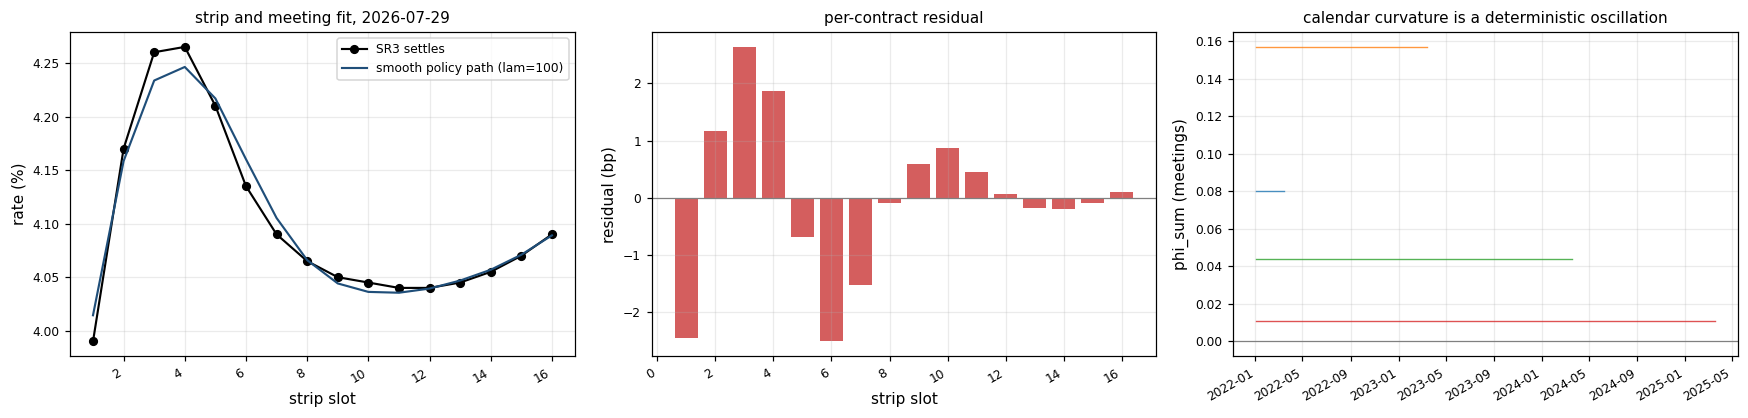

In [12]:
d = lab3["slot_panel"].dropna().index[-1]
r_slots = resid_slots(CONFIG["lam"])
fig, axes = plt.subplots(1, 3, figsize=(16, 3.9))
y = lab3["slot_panel"].loc[d].dropna()
x = np.array([int(c) for c in y.index])
fit = y.to_numpy() - r_slots.loc[d, x].to_numpy() / 100.0
axes[0].plot(x, y.to_numpy(), "o-", color="black", lw=1.4, ms=5, label="SR3 settles")
axes[0].plot(x, fit, lw=1.4, color="#1f4e79", label=f"smooth policy path (lam={CONFIG['lam']:.0f})")
axes[0].set_xlabel("strip slot")
axes[0].set_ylabel("rate (%)")
axes[0].set_title(f"strip and meeting fit, {pd.Timestamp(d).date()}", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].bar(x, r_slots.loc[d, x].to_numpy(), color="#c62828", alpha=0.75)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_xlabel("strip slot")
axes[1].set_ylabel("residual (bp)")
axes[1].set_title("per-contract residual", fontsize=10)
phi_ts = lab3["phi"]
for c in list(phi_ts.columns)[:4]:
    axes[2].plot(phi_ts.index, phi_ts[c].to_numpy(), lw=0.9, alpha=0.8)
axes[2].axhline(0, color="grey", lw=0.8)
axes[2].set_ylabel("phi_sum (meetings)")
axes[2].set_title("calendar curvature is a deterministic oscillation", fontsize=10)
for a in axes:
    a.tick_params(labelsize=8)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 4. The pond test — is there enough movement to pay for the trade?

The prior lab established that fading SR3 flies is *directionally* right and
still loses money, because the moves are barely larger than the round trip.
That reframes what a new signal has to do: **call the sign more often, or
select days on which the fly moves further.** The second is measurable before
any backtest, and it can end a definition without running a grid.

`oracle_bp` is `E[|level[t+h] − level[t]|]` on the days a signal fires — what
a trader with perfect foresight of the *direction* would capture, and a
ceiling no signal work can exceed. `selectivity` of 1.00 means the signal
picks days at random with respect to move size.

In [13]:
sig3 = {
    "K0 raw z": zscore_signal(lab3["levels"], window=120),
    "K1 meeting resid (scale)": scale_only_zscore(mres3, window=120),
    "K1z meeting resid (z)": zscore_signal(mres3, window=120),
    "K2 calendar-tilted z": zscore_signal(tilt3, window=120),
}
print("### 3m FLIES")
pond3 = K.pond_block(lab3["levels"], sig3, entry_z=2.0, gate=lab3["gate"],
                     horizons=CONFIG["horizons"], round_trip_bp=CONFIG["cost_bp"],
                     tag="3m")

### 3m FLIES

POND TEST (|forward move| on the days each signal fires, entry |z| >= 2.0, round trip 2.0bp)
  selectivity 1.00 = the signal picks days at random with respect to move size
                  signal  horizon     n  mean_abs_bp  selectivity  median_abs_bp  p90_abs_bp  oracle_net_bp  p_beat_cost  mean_bp  sd_bp
           unconditional        5 15926        0.953        1.000           0.50         2.5         -1.047        0.119    0.070  1.870
           unconditional       10 15766        1.268        1.000           0.50         3.0         -0.732        0.168    0.137  2.461
           unconditional       21 15414        1.774        1.000           0.75         4.5         -0.226        0.237    0.275  3.382
                K0 raw z        5  2210        1.382        1.451           0.75         3.5         -0.618        0.192    0.006  2.532
                K0 raw z       10  2192        1.753        1.383           1.00         4.5         -0.247        0.266    0.040

In [14]:
sig6 = {
    "K0 raw z": zscore_signal(lab6["levels"], window=120),
    "K1 meeting resid (scale)": scale_only_zscore(mres6, window=120),
    "K1z meeting resid (z)": zscore_signal(mres6, window=120),
    "K2 calendar-tilted z": zscore_signal(tilt6, window=120),
}
print("### 6m FLIES")
pond6 = K.pond_block(lab6["levels"], sig6, entry_z=2.0, gate=lab6["gate"],
                     horizons=CONFIG["horizons"], round_trip_bp=CONFIG["cost_bp"],
                     tag="6m")
print(f"\n  3m pooled fly sd {lab3['levels'].stack().std():.2f}bp vs "
      f"6m {lab6['levels'].stack().std():.2f}bp "
      f"({lab6['levels'].stack().std() / lab3['levels'].stack().std():.2f}x) "
      f"for the SAME three-leg, four-contract cost.")
print("  The 3m fly's oracle barely clears the round trip even at h=21; the 6m")
print("  fly's clears it by 4bp. If anything is tradeable it is the 6m fly.")

### 6m FLIES

POND TEST (|forward move| on the days each signal fires, entry |z| >= 2.0, round trip 2.0bp)
  selectivity 1.00 = the signal picks days at random with respect to move size
                  signal  horizon     n  mean_abs_bp  selectivity  median_abs_bp  p90_abs_bp  oracle_net_bp  p_beat_cost  mean_bp  sd_bp
           unconditional        5 13638        2.560        1.000            1.0        6.50          0.560        0.339    0.133  4.902
           unconditional       10 13488        3.520        1.000            1.5        9.00          1.520        0.430    0.252  6.514
           unconditional       21 13158        5.103        1.000            2.0       13.50          3.103        0.516    0.515  9.373
                K0 raw z        5  2196        3.198        1.249            1.5        8.00          1.198        0.438   -0.041  5.435
                K0 raw z       10  2184        4.437        1.260            2.5       11.00          2.437        0.538   -0.050

## 5. Placebo calendars — is it the meetings, or just smoothing?

This is the section the hypothesis has to survive. The meeting residual is
built from a basis with a lot of freedom, and *any* flexible smoother will
leave a residual that mean-reverts better than the raw fly. So the real
calendar is run against decoys with the same number of knots:

* **shifted** — the real dates moved bodily by 21 / 45 days: same count, same
  irregularity, wrong phase against the IMM grid;
* **evenly spaced** — eight pseudo-meetings a year at exactly equal spacing:
  same count, *no* irregularity at all, so it cannot possibly carry calendar
  information;
* **cubic spline in slot index** — the existing `curvefit_residual_signal`,
  which assumes the strip should be smooth in calendar time.

Each decoy's `lam` is tuned so its residual has the **same standard deviation**
as the real calendar's, because a basis with more effective freedom trivially
explains more variance. With the scale matched, `1 − var(resid)/var(fly)` is
identical by construction and carries no information; the discriminating
statistics are the residual's **forward-predictive IC** and its **backtest**.

In [15]:
REAL = fomc_decisions(datetime.date(2017, 1, 1), datetime.date(2032, 12, 31))
LAB, LVL = lab6, lab6["levels"]              # the 6m fly, where the pond is
TARGET_SD = float(resid_fly(LAB, CONFIG["lam"]).stack().std())
print(f"real-calendar residual sd on the 6m fly = {TARGET_SD:.3f}bp "
      f"(raw fly sd {LVL.stack().std():.3f}bp)")


def tune_lam(meetings, tag, target=TARGET_SD, lo=0.05, hi=1.0e6, iters=24):
    for _ in range(iters):
        mid = float(np.sqrt(lo * hi))
        if float(resid_fly(LAB, mid, meetings, tag).stack().std()) < target:
            lo = mid
        else:
            hi = mid
    return float(np.sqrt(lo * hi))


DECOYS = {
    "shift +21d": [d + datetime.timedelta(days=21) for d in REAL],
    "shift +45d": [d + datetime.timedelta(days=45) for d in REAL],
    "even 8/yr": [datetime.date(2018, 1, 31) + datetime.timedelta(days=int(round(45.656 * i)))
                  for i in range(140)],
}
panels = {"E. real FOMC calendar": resid_fly(LAB, CONFIG["lam"])}
lam_of = {"E. real FOMC calendar": CONFIG["lam"]}
for nm, mt in DECOYS.items():
    lam = tune_lam(mt, nm)
    lam_of[f"B. {nm}"] = lam
    panels[f"B. {nm}"] = resid_fly(LAB, lam, mt, nm)
panels["B. cubic spline in slot"] = curvefit_residual_signal(
    LAB["slot_panel"], LAB["struct"], form="spline", scale=100.0).reindex(
    index=LVL.index, columns=LVL.columns)
lam_of["B. cubic spline in slot"] = np.nan
panels["A. raw fly (no smoothing)"] = LVL
lam_of["A. raw fly (no smoothing)"] = np.nan

# Every residual panel is a deviation from a fitted fair value, so its zero is
# meaningful and `scale_only_zscore` (divide by a trailing sd, keep the zero) is
# the right standardisation. The RAW FLY's zero is NOT meaningful -- a 6m fly
# that sits at -13bp for a year is not a permanent two-sigma dislocation -- so
# standardising it the same way would hand the baseline a handicap and
# manufacture the comparison. It gets a full trailing z-score, which is also
# exactly the incumbent K0 definition. Both versions are reported so the choice
# is visible rather than assumed.
STD_OF = {n: "scale" for n in panels}
STD_OF["A. raw fly (no smoothing)"] = "z"
panels["A2. raw fly, scale-only (handicapped control)"] = LVL
lam_of["A2. raw fly, scale-only (handicapped control)"] = np.nan
STD_OF["A2. raw fly, scale-only (handicapped control)"] = "scale"


def _std(panel, how, window):
    return (zscore_signal(panel, window=window) if how == "z"
            else scale_only_zscore(panel, window=window))


print(f"  built {len(panels)} panels ({time.time() - T0:.0f}s)")

real-calendar residual sd on the 6m fly = 5.661bp (raw fly sd 19.998bp)


  built 7 panels (222s)


In [16]:
from scipy.stats import spearmanr

fwd = {h: LVL.shift(-h) - LVL for h in CONFIG["horizons"]}
rows = []
for name, p in panels.items():
    # Score each basis on the SAME object the backtest trades, i.e. after its
    # own standardisation. Comparing demeaned residual panels against an
    # undemeaned raw level would make the raw-fly row measure maturity ranking
    # rather than dislocation.
    q = _std(p, STD_OF[name], 120)
    row = {"basis": name, "lam": lam_of[name],
           "resid_sd_bp": float(p.stack().std()), "standardise": STD_OF[name]}
    for h, f in fwd.items():
        ics = []
        for d in q.index:
            a, b = q.loc[d].to_numpy(float), f.loc[d].to_numpy(float)
            ok = np.isfinite(a) & np.isfinite(b)
            if ok.sum() < 6 or np.unique(a[ok]).size < 4:
                continue
            ic = spearmanr(a[ok], b[ok]).correlation
            if np.isfinite(ic):
                ics.append(ic)
        ics = np.asarray(ics)
        row[f"xs_ic_h{h}"] = float(ics.mean()) if ics.size else np.nan
        row[f"t_h{h}"] = (float(ics.mean() / ics.std(ddof=1) * np.sqrt(ics.size))
                          if ics.size > 3 else np.nan)
    rows.append(row)
ic_tab = pd.DataFrame(rows)
print("per-date cross-sectional IC vs the forward move, on each basis's own "
      "traded signal (6m flies)")
print(ic_tab.round(4).to_string(index=False))
print("\n  negative IC = the signal mean-reverts (rich now -> falls).")
print("  t is NOT overlap-corrected: read it as an ordering, not a p-value.")
ic_tab.to_csv(K.DATA_DIR / "placebo_ic.csv", index=False)

per-date cross-sectional IC vs the forward move, on each basis's own traded signal (6m flies)
                                        basis      lam  resid_sd_bp standardise  xs_ic_h5     t_h5  xs_ic_h10    t_h10  xs_ic_h21    t_h21
                        E. real FOMC calendar 100.0000       5.6611       scale   -0.1267 -11.2172    -0.1414 -13.2399    -0.1753 -16.4088
                                B. shift +21d 100.4457       5.6611       scale   -0.1291 -11.3050    -0.1459 -13.3981    -0.1811 -16.7841
                                B. shift +45d 104.1760       5.6611       scale   -0.1329 -11.6601    -0.1503 -13.7451    -0.1856 -17.2075
                                 B. even 8/yr 102.8452       5.6611       scale   -0.1270 -11.1106    -0.1446 -13.2442    -0.1770 -16.3796
                      B. cubic spline in slot      NaN       4.4591       scale   -0.1238 -12.2294    -0.1441 -14.2168    -0.1737 -17.2719
                    A. raw fly (no smoothing)      NaN      19.9984     

In [17]:
from RVUtils.MeanRev import grid_search

PLACEBO_GRID = {"window": CONFIG["windows"], "entry_z": CONFIG["entry_zs"],
                "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}
rows = []
for name, p in panels.items():
    fn = (lambda pp, hh: (lambda L, window: _std(pp, hh, window)))(p, STD_OF[name])
    g = grid_search(PLACEBO_GRID, levels=LVL, signal=None, gate=LAB["gate"],
                    base=BASE, signal_fn=fn)
    d = g["total_net_bp"]
    best = g.loc[d.idxmax()]
    rows.append({
        "basis": name, "standardise": STD_OF[name], "n_configs": len(g),
        "grid_median_bp": d.median(),
        "pct_positive": float((d > 0).mean()), "best_net_bp": d.max(),
        "best_n_trades": int(best["n_trades"]),
        "best_avg_net_bp": best["avg_net_bp"], "best_hit": best["hit_rate"],
        "best_sharpe": best["sharpe"],
        "fade_median": g[g["direction"] == "fade"]["total_net_bp"].median(),
        "mom_median": g[g["direction"] == "momentum"]["total_net_bp"].median(),
        "best_config": best["config"]})
placebo = pd.DataFrame(rows)
print("PLACEBO BACKTEST (6m flies, identical grid / engine / 2.0bp cost)")
print(placebo.drop(columns=["best_config"]).round(3).to_string(index=False))
print("\nbest config per basis:")
for _, r in placebo.iterrows():
    print(f"  {r['basis']:44s} {r['best_config']}")
placebo.to_csv(K.DATA_DIR / "placebo_backtest.csv", index=False)

pl = placebo.set_index("basis")
decoys = [b for b in pl.index if b.startswith("B.")]
mtg = [b for b in pl.index if b.startswith("B. shift") or b.startswith("B. even")]
real = "E. real FOMC calendar"
raw = "A. raw fly (no smoothing)"
spline = "B. cubic spline in slot"


def _rng(col):
    return pl.loc[decoys, col].min(), pl.loc[decoys, col].max()


def _inside(col):
    lo, hi = _rng(col)
    return bool(lo <= pl.loc[real, col] <= hi)


beat_raw_best = [b for b in decoys + [real] if pl.loc[b, "best_net_bp"] > pl.loc[raw, "best_net_bp"]]
beat_raw_med = [b for b in decoys + [real] if pl.loc[b, "grid_median_bp"] > pl.loc[raw, "grid_median_bp"]]
best_ic = ic_tab.set_index("basis")["xs_ic_h21"].idxmin()
print(f"""
  READ THIS ROW BY ROW, AND BE PRECISE ABOUT WHICH COLUMN -- the columns do not
  agree, and saying "every smoothed basis beats the raw fly" would be false.

  * ON BEST CONFIG, smoothing wins outright: {len(beat_raw_best)} of {len(decoys) + 1} smoothed bases beat the
    raw fly's {pl.loc[raw, 'best_net_bp']:+.1f}bp.
  * ON THE GRID MEDIAN it does NOT: only {len(beat_raw_med)} of {len(decoys) + 1} beat the raw fly's
    {pl.loc[raw, 'grid_median_bp']:+.1f}bp, and the meeting bases sit BELOW it
    ({pl.loc[mtg, 'grid_median_bp'].min():+.1f} to {pl.loc[mtg, 'grid_median_bp'].max():+.1f}). A better best corner with a worse
    median is a WIDER sweep, not a better signal -- the signature of a noisier
    input, not a more informative one.
  * The real calendar is inside the decoy range on best config: {_inside('best_net_bp')};
    on grid median: {_inside('grid_median_bp')}. It owns the single best corner, which is what a
    72-config search hands to whichever basis is luckiest.
  * On the forward-predictive IC at h=21 -- the statistic that does NOT depend
    on picking a corner -- the best basis is "{best_ic}",
    and the decoys include an EVENLY SPACED pseudo-calendar that by
    construction carries no calendar information at all.
  * The one basis that improves BOTH the best config and the distribution is a
    plain cubic spline in slot index, which needs no calendar:
    median {pl.loc[spline, 'grid_median_bp']:+.1f}bp, {pl.loc[spline, 'pct_positive']:.1%} of configs positive, Sharpe {pl.loc[spline, 'best_sharpe']:+.2f}.
  * NOT ONE BASIS HAS A POSITIVE GRID MEDIAN.""")

PLACEBO BACKTEST (6m flies, identical grid / engine / 2.0bp cost)
                                        basis standardise  n_configs  grid_median_bp  pct_positive  best_net_bp  best_n_trades  best_avg_net_bp  best_hit  best_sharpe  fade_median  mom_median
                        E. real FOMC calendar       scale         72        -631.625         0.042       187.25            224            0.836     0.393        0.311     -287.750    -931.375
                                B. shift +21d       scale         72        -623.125         0.028        99.00            155            0.639     0.342        0.204     -293.750    -895.125
                                B. shift +45d       scale         72        -671.000         0.028       143.75            158            0.910     0.348        0.295     -245.625    -906.375
                                 B. even 8/yr       scale         72        -624.500         0.028        55.25            160            0.345     0.362        0.113

## 6. The frameworks — 3m flies

From here the house machinery does the work: grid → distribution →
neighbourhood → sign test → best config → equity in bp and $ → trade log →
exit comparison → cost curve → regime split → linear-shadow decomposition →
median-config control → league rows. The top row is never the verdict.


### GRID  (32 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -528.62bp | IQR [-771.94, -386.50] | 0% net-positive | best -127.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.5         z0      fade       109     0.220      -1.170       -127.50      -318750.0  -0.575    -139.75
    250      2.5        t42      fade       112     0.161      -1.645       -184.25      -460625.0  -0.772    -212.00
    120      2.5        t42      fade       137     0.204      -1.498       -205.25      -513125.0  -0.997    -214.75
    250      2.5        t21      fade       161     0.168      -1.413       -227.50      -568750.0  -1.513    -237.00
    120      2.5         z0      fade       139     0.173      -1.750       -243.25      -608125.0  -1.039    -247.25
    120      2.5        t21      fade       175     0.171      -1.473       -257.75      -644375.0  -1.607    -267.75
    250     

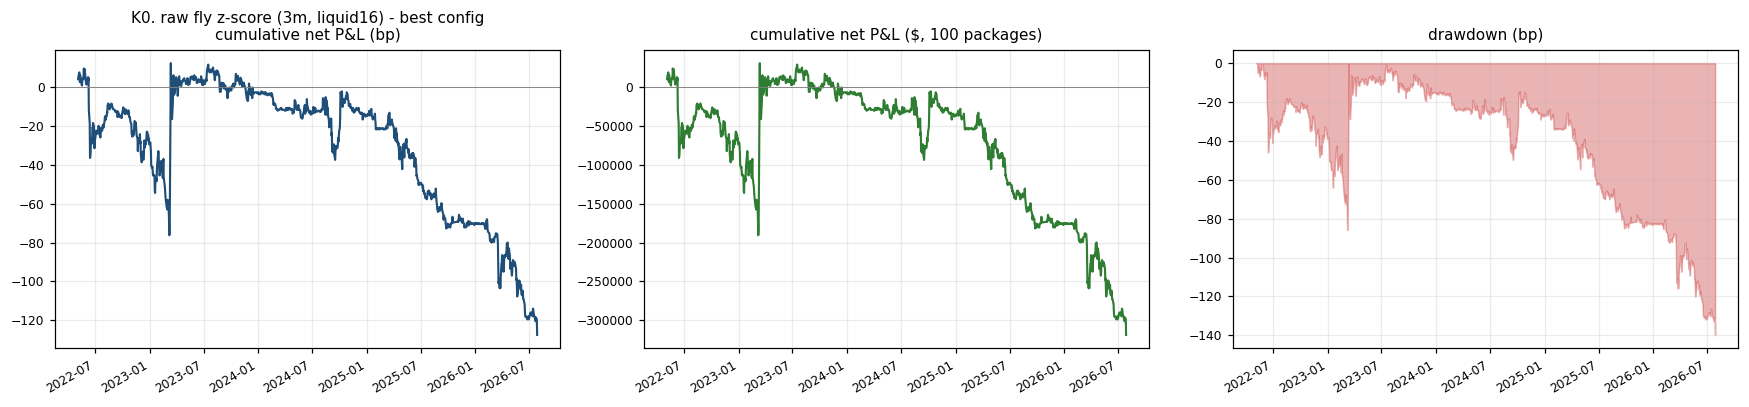


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
M22-U22-Z22   -1  2022-05-03 2022-05-04 2022-06-14    28  2.545     37.50      60.00     -22.5      2.0   -24.5 -61250.0       max_hold
U22-Z22-H23   -1  2022-05-17 2022-05-18 2022-08-18    63  2.516     20.50      33.00     -12.5      2.0   -14.5 -36250.0       max_hold
Z22-H23-M23   -1  2022-06-10 2022-06-13 2022-07-14    21  2.565     35.00      14.50      20.5      2.0    18.5  46250.0 mean_reversion
Z24-H25-M25    1  2022-06-17 2022-06-21 2022-09-20    63 -3.057     -2.50      -2.00       0.5      2.0    -1.5  -3750.0       max_hold
H23-M23-U23    1  2022-07-05 2022-07-06 2022-08-26    37 -2.562     -1.00       9.50      10.5      2.0     8.5  21250.0 mean_reversion
U24-Z24-H25    1  2022-07-14 2022-07-15 2022-10-13    63 -2.968     -1.00      -2.00      -1.0      2.0    -3.0  -7500.0       max_hold
H25-M25-U25    1  202

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       109    39.394     0.220      -1.170       -127.50  -0.575
band       118    31.831     0.237      -1.400       -165.25  -0.799
  t5       304     4.964     0.105      -1.680       -510.75  -4.574
 t10       225     9.853     0.138      -1.390       -312.75  -2.086
 t21       161    20.205     0.168      -1.413       -227.50  -1.513
 t42       112    40.429     0.161      -1.645       -184.25  -0.772

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 109          90.5        0.83     0.560       226250.0
           0.5 109          36.0        0.33     0.367        90000.0
           1.0 109         -18.5       -0.17     0.284       -46250.0
           1.5 109         -73.0       -0.67     0.266      -182500.0
           2.0 109        -127.5       -1.17     0.220      -318750.0
           2.5 109        -182.0       -1.6


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0       109            90.5        -127.5      -1.170     0.220  -0.575     -139.8      39.4          False             False
         belly       1            1            0.5       109          1137.0        1082.5       9.931     0.578   0.830     -379.5      39.4           True              True
belly_vs_front       2            2            1.0       109          -243.0        -352.0      -3.229     0.220  -1.069     -379.5      39.4          False             False
 belly_vs_back       2            2            1.0       109           333.5         224.5       2.060     0.523   0.948      -89.0      39.4           True              True
  -> SHADOWED - a simpler instrument beats the fly o

In [18]:
GRID = {"window": CONFIG["windows"], "entry_z": CONFIG["entry_zs"],
        "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}
PARAMS = ["window", "entry_z", "exit_style", "direction"]
#  the exit-comparison table shows the swept exits plus the two signal-driven
#  rules the grid does not carry, so 'exit at fitted fair value' (z0) can be
#  read against a fixed horizon directly.
EXITS = ("z0", "band", "t5", "t10", "t21", "t42")


def k0(L, window):
    return zscore_signal(L, window=window)


out_k0_3 = K.run_family("K0. raw fly z-score (3m, liquid16)", lab=lab3,
                        signal_fn=k0, grid_spec=GRID, params=PARAMS, base=BASE,
                        cls="kink", note="the incumbent definition, reproduced "
                                         "at per-CONTRACT costs", exits=EXITS)


### GRID  (32 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -725.25bp | IQR [-1031.19, -461.50] | 0% net-positive | best -143.75bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.5        t42      fade       140     0.229      -1.027       -143.75      -359375.0  -0.765    -176.50
    250      2.5         z0      fade       140     0.264      -1.120       -156.75      -391875.0  -0.719    -184.25
    120      2.5         z0      fade       189     0.243      -0.995       -188.00      -470000.0  -0.814    -227.75
    250      2.0        t42      fade       186     0.210      -1.126       -209.50      -523750.0  -1.038    -242.25
    120      2.5        t42      fade       195     0.200      -1.142       -222.75      -556875.0  -1.184    -277.25
     60      2.5         z0      fade       240     0.225      -0.986       -236.75      -591875.0  -1.013    -258.25
    250    

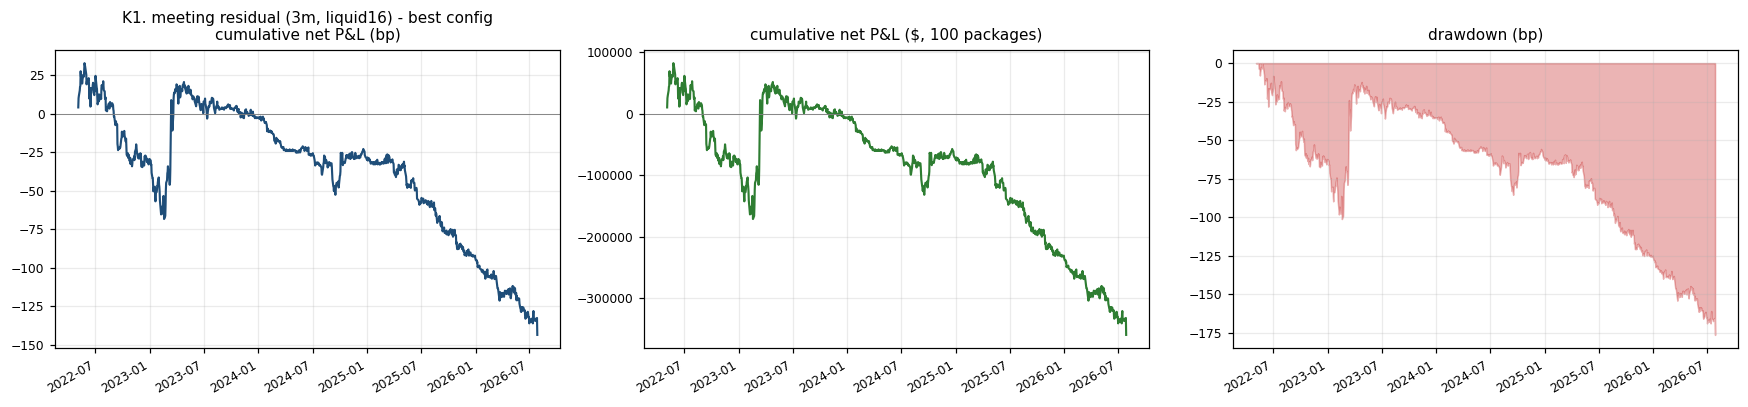


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
U22-Z22-H23    1  2022-05-02 2022-05-03 2022-07-05    42 -4.501      12.5      32.50     20.00      2.0   18.00  45000.0        time
M25-U25-Z25    1  2022-05-02 2022-05-03 2022-07-05    42 -2.525      -2.5      -1.00      1.50      2.0   -0.50  -1250.0        time
M22-U22-Z22   -1  2022-05-02 2022-05-03 2022-06-14    29  2.918      42.5      60.00    -17.50      2.0  -19.50 -48750.0        time
Z22-H23-M23   -1  2022-05-05 2022-05-06 2022-07-08    42  3.946      20.0      23.50     -3.50      2.0   -5.50 -13750.0        time
H23-M23-U23   -1  2022-05-06 2022-05-09 2022-07-11    42  3.297      17.5      -0.50     18.00      2.0   16.00  40000.0        time
Z24-H25-M25    1  2022-06-14 2022-06-15 2022-08-16    42 -3.238      -2.0      -2.50     -0.50      2.0   -2.50  -6250.0        time
U24-Z24-H25   -1  2022-06-29 2022-06-30 20

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       140    34.350     0.264      -1.120       -156.75  -0.719
band       155    28.226     0.232      -1.326       -205.50  -1.090
  t5       429     4.977     0.110      -1.705       -731.25  -4.714
 t10       302     9.788     0.129      -1.535       -463.50  -2.884
 t21       206    20.204     0.170      -1.374       -283.00  -1.647
 t42       140    39.043     0.229      -1.027       -143.75  -0.765

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 140        136.25       0.973     0.486       340625.0
           0.5 140         66.25       0.473     0.386       165625.0
           1.0 140         -3.75      -0.027     0.307        -9375.0
           1.5 140        -73.75      -0.527     0.243      -184375.0
           2.0 140       -143.75      -1.027     0.229      -359375.0
           2.5 140       -213.75      -1.52


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0       140           136.2        -143.8      -1.027     0.229  -0.765     -176.5      39.0          False             False
         belly       1            1            0.5       140          -141.5        -211.5      -1.511     0.443  -0.212     -534.0      39.0          False              True
belly_vs_front       2            2            1.0       140            54.2         -85.8      -0.613     0.371  -0.340     -197.8      39.0           True              True
 belly_vs_back       2            2            1.0       140            82.0         -58.0      -0.414     0.400  -0.302     -175.0      39.0           True              True
  -> SHADOWED - a simpler instrument beats the fly o

In [19]:
def k1_3(L, window):
    return scale_only_zscore(mres3, window=window)


out_k1_3 = K.run_family("K1. meeting residual (3m, liquid16)", lab=lab3,
                        signal_fn=k1_3, grid_spec=GRID, params=PARAMS, base=BASE,
                        cls="kink", note=f"smooth-policy-path residual, lam="
                                         f"{CONFIG['lam']:.0f}, model's zero kept", exits=EXITS)


### GRID  (32 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -549.62bp | IQR [-771.19, -382.44] | 0% net-positive | best -141.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.5         z0      fade        98     0.224      -1.439       -141.00      -352500.0  -0.657    -150.75
    250      2.5        t42      fade       108     0.176      -1.428       -154.25      -385625.0  -0.567    -222.75
    120      2.5        t42      fade       137     0.212      -1.268       -173.75      -434375.0  -0.761    -203.00
    250      2.5        t21      fade       155     0.174      -1.360       -210.75      -526875.0  -1.374    -236.75
    120      2.5        t21      fade       170     0.165      -1.371       -233.00      -582500.0  -1.526    -244.25
    250      2.0         z0      fade       196     0.163      -1.274       -249.75      -624375.0  -0.903    -278.00
    250     

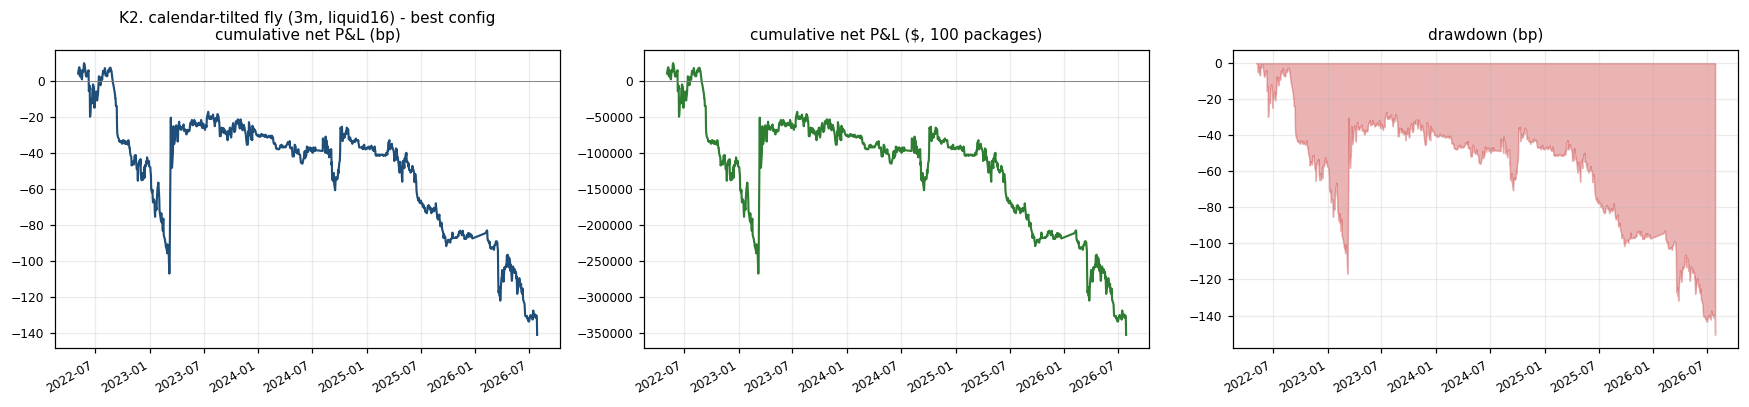


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
M22-U22-Z22   -1  2022-05-03 2022-05-04 2022-06-14    28  2.599     37.50      60.00    -22.50      2.0  -24.50 -61250.0       max_hold
Z22-H23-M23   -1  2022-06-10 2022-06-13 2022-07-13    20  2.540     35.00       8.00     27.00      2.0   25.00  62500.0 mean_reversion
U22-Z22-H23   -1  2022-06-13 2022-06-14 2022-09-14    63  3.523     37.00      64.75    -27.75      2.0  -29.75 -74375.0       max_hold
Z24-H25-M25    1  2022-06-17 2022-06-21 2022-09-20    63 -3.063     -2.50      -2.00      0.50      2.0   -1.50  -3750.0       max_hold
U24-Z24-H25    1  2022-07-14 2022-07-15 2022-10-13    63 -2.830     -1.00      -2.00     -1.00      2.0   -3.00  -7500.0       max_hold
H25-M25-U25    1  2022-07-28 2022-07-29 2022-08-29    21 -2.515     -3.00      -1.00      2.00      2.0    0.00      0.0 mean_reversion
U25-Z25-H26    1  202

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0        98    42.776     0.224      -1.439       -141.00  -0.657
band       107    35.458     0.224      -1.675       -179.25  -0.812
  t5       300     4.977     0.097      -1.892       -567.50  -5.501
 t10       218     9.931     0.142      -1.400       -305.25  -1.959
 t21       155    20.516     0.174      -1.360       -210.75  -1.374
 t42       108    40.620     0.176      -1.428       -154.25  -0.567

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 98          55.0       0.561     0.531       137500.0
           0.5 98           6.0       0.061     0.388        15000.0
           1.0 98         -43.0      -0.439     0.306      -107500.0
           1.5 98         -92.0      -0.939     0.286      -230000.0
           2.0 98        -141.0      -1.439     0.224      -352500.0
           2.5 98        -190.0      -1.939     0


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        98            55.0        -141.0      -1.439     0.224  -0.657     -150.8      42.8          False             False
         belly       1            1            0.5        98          1218.5        1169.5      11.934     0.592   1.005     -393.0      42.8           True              True
belly_vs_front       2            2            1.0        98          -294.5        -392.5      -4.005     0.224  -1.219     -441.5      42.8          False             False
 belly_vs_back       2            2            1.0        98           349.5         251.5       2.566     0.592   1.059      -79.5      42.8           True              True
  -> SHADOWED - a simpler instrument beats the fly o

In [20]:
def k2_3(L, window):
    return zscore_signal(tilt3, window=window)


out_k2_3 = K.run_family("K2. calendar-tilted fly (3m, liquid16)", lab=lab3,
                        signal_fn=k2_3, grid_spec=GRID, params=PARAMS, base=BASE,
                        cls="kink", note="fly - phi*pace; no fitting, no history", exits=EXITS)

## 7. The frameworks — 6m flies

The 6m fly carries ~2.9x the dispersion of the 3m fly for the identical
four-contract cost, and it is the only structure in either lab whose oracle
bound clears the round trip with room to spare.


### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -474.75bp | IQR [-708.69, -333.56] | 0% net-positive | best -43.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    120      2.5        t21      fade       159     0.333      -0.274        -43.50      -108750.0  -0.132    -142.00
    250      2.5        t42      fade        99     0.273      -0.652        -64.50      -161250.0  -0.101    -323.25
    250      2.0        t42      fade       153     0.320      -0.426        -65.25      -163125.0  -0.091    -232.00
    250      2.5        t21      fade       142     0.310      -0.646        -91.75      -229375.0  -0.166    -320.00
     60      2.5        t42  momentum       155     0.329      -0.711       -110.25      -275625.0  -0.196    -286.25
     60      2.5         z0  momentum       175     0.246      -0.637       -111.50      -278750.0  -0.206    -288.00
     60      

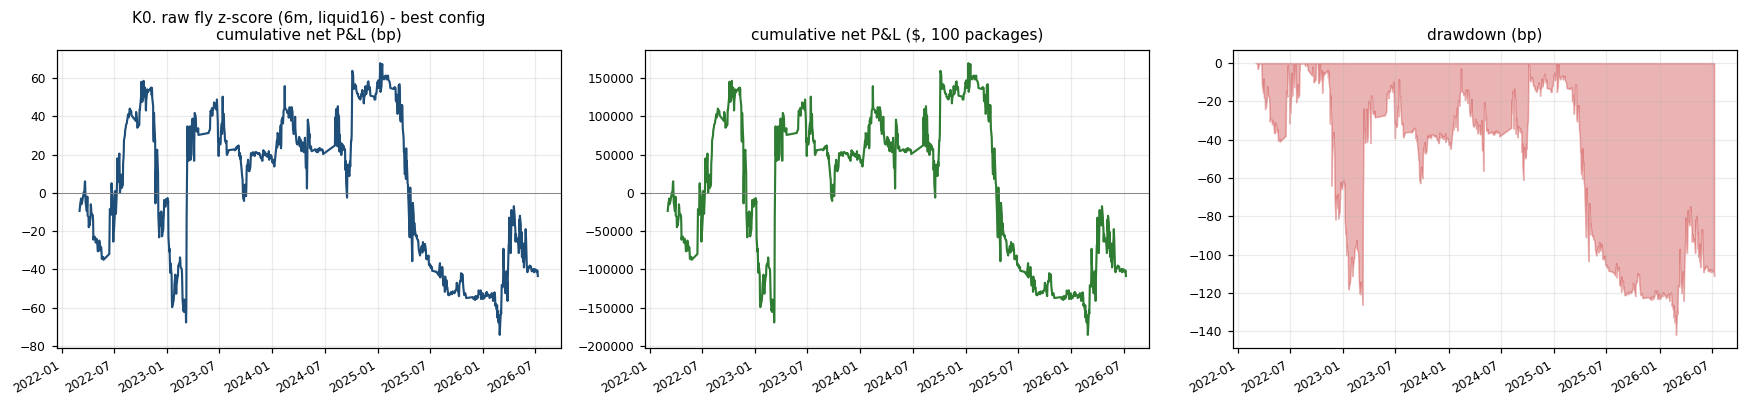


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
U23-H24-U24    1  2022-03-02 2022-03-03 2022-04-01    21 -2.684     -0.50      -3.50     -3.00      2.0   -5.00 -12500.0        time
Z23-M24-Z24    1  2022-03-02 2022-03-03 2022-04-01    21 -2.593    -13.00      -6.00      7.00      2.0    5.00  12500.0        time
Z24-M25-Z25    1  2022-03-04 2022-03-07 2022-04-05    21 -2.562     -5.50      -4.50      1.00      2.0   -1.00  -2500.0        time
H23-U23-H24   -1  2022-03-14 2022-03-15 2022-04-13    21  2.566     34.00      38.00     -4.00      2.0   -6.00 -15000.0        time
M22-Z22-M23   -1  2022-03-21 2022-03-22 2022-04-21    21  2.512     54.50      69.00    -14.50      2.0  -16.50 -41250.0        time
U23-H24-U24    1  2022-04-13 2022-04-14 2022-05-16    21 -2.644    -11.00      -9.50      1.50      2.0   -0.50  -1250.0        time
M23-Z23-M24    1  2022-04-26 2022-04-27 20

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       125    38.176     0.360      -2.494       -311.75  -0.692
band       129    31.558     0.318      -3.331       -429.75  -1.002
  t5       273     4.989     0.198      -1.513       -413.00  -2.132
 t10       212     9.929     0.264      -1.577       -334.25  -1.256
 t21       159    20.767     0.333      -0.274        -43.50  -0.132
 t42       122    41.303     0.320      -1.850       -225.75  -0.573

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 159         274.5       1.726     0.566       686250.0
           0.5 159         195.0       1.226     0.503       487500.0
           1.0 159         115.5       0.726     0.409       288750.0
           1.5 159          36.0       0.226     0.365        90000.0
           2.0 159         -43.5      -0.274     0.333      -108750.0
           2.5 159        -123.0      -0.77

K0. raw fly z-score (6m, liquid16) - MEDIAN config (the anti-selection control)  |  momentum|z1.5|t42|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   231   skipped    0   hit 30%   avg -2.049bp   avg hold 40.5d
  total    -473.25bp   $   -1,183,125   gross -11.25bp
  daily-MTM Sharpe -0.71   maxDD -733.25bp ($-1,833,125)   worst trade -77.00bp
  t(trade) -2.04   NW t(daily) -1.49   non-overlap SR -0.22   DSR p=0.000 over 72 trials

  LEAGUE ROW  K0. raw fly z-score (6m, liquid16) / best-config: MARGINAL-maker-only  (taker -43.50bp, maker +274.50bp, DSR p=0.001)

  LEAGUE ROW  K0. raw fly z-score (6m, liquid16) / median-config: DEAD  (taker -473.25bp, maker -11.25bp, DSR p=0.000)


In [21]:
out_k0_6 = K.run_family("K0. raw fly z-score (6m, liquid16)", lab=lab6,
                        signal_fn=k0, grid_spec=GRID, params=PARAMS, base=BASE,
                        cls="kink", note="the incumbent definition on 6m flies", exits=EXITS)


### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -631.62bp | IQR [-1042.88, -295.12] | 4% net-positive | best +187.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     60      2.5         z0      fade       224     0.393       0.836        187.25       468125.0   0.311    -161.75
    120      2.5         z0      fade       162     0.370       0.753        122.00       305000.0   0.238    -214.00
    250      2.5         z0      fade       106     0.377       0.233         24.75        61875.0   0.052    -182.50
    120      2.0         z0      fade       226     0.332      -0.189        -42.75      -106875.0  -0.085    -252.25
    250      2.0         z0      fade       163     0.374      -0.400        -65.25      -163125.0  -0.142    -258.25
    250      1.5         z0      fade       242     0.326      -0.377        -91.25      -228125.0  -0.183    -220.75
    120    

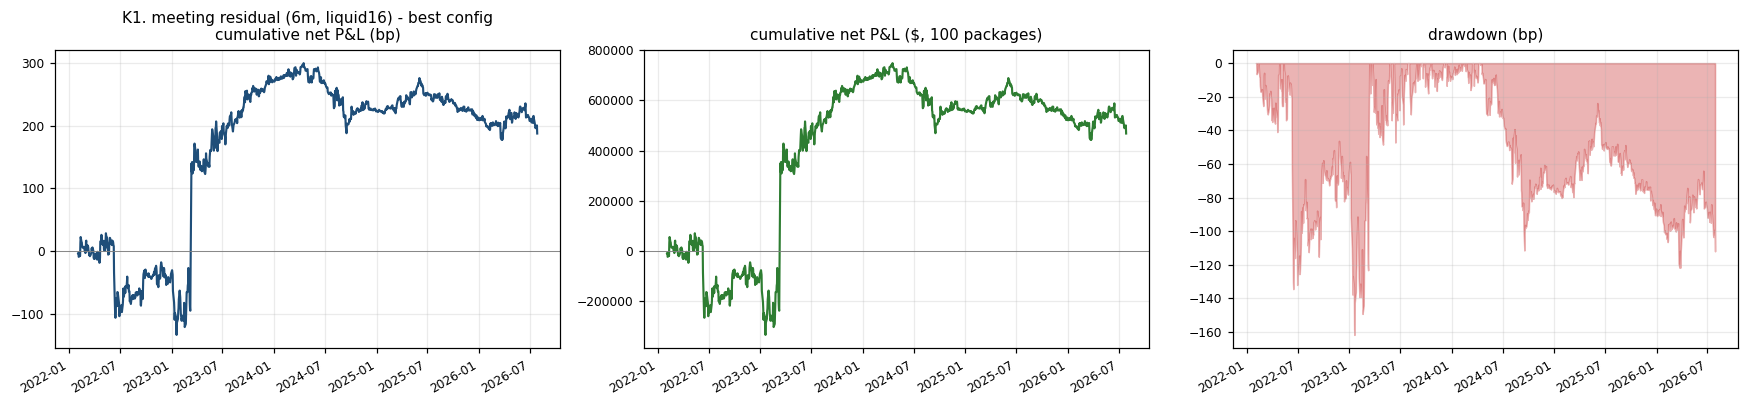


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp   net_usd    exit_reason
M24-Z24-M25   -1  2022-01-31 2022-02-01 2022-05-03    63  4.014       1.5        2.0      -0.5      2.0    -2.5   -6250.0       max_hold
U22-H23-U23   -1  2022-01-31 2022-02-01 2022-02-14     9  2.669      21.5       30.5      -9.0      2.0   -11.0  -27500.0 mean_reversion
Z23-M24-Z24    1  2022-01-31 2022-02-01 2022-05-03    63 -4.236      -1.5       -9.0      -7.5      2.0    -9.5  -23750.0       max_hold
Z24-M25-Z25    1  2022-01-31 2022-02-01 2022-02-14     9 -2.598      -2.5       -5.0      -2.5      2.0    -4.5  -11250.0 mean_reversion
M22-Z22-M23    1  2022-02-02 2022-02-03 2022-03-28    36 -2.551      17.5       66.0      48.5      2.0    46.5  116250.0 mean_reversion
U24-H25-U25   -1  2022-02-02 2022-02-03 2022-05-05    63  3.791      -1.0       -0.5      -0.5      2.0    -2.5   -6250.0       max_hold
Z22-M23-Z23   

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       224    34.871     0.393       0.836        187.25   0.311
band       250    28.548     0.344      -0.189        -47.25  -0.090
  t5       849     4.969     0.186      -1.684      -1429.75  -4.244
 t10       582     9.868     0.244      -1.241       -722.50  -1.894
 t21       356    20.396     0.312      -1.025       -365.00  -0.793
 t42       225    39.573     0.373      -0.790       -177.75  -0.352

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 224        635.25       2.836     0.598      1588125.0
           0.5 224        523.25       2.336     0.536      1308125.0
           1.0 224        411.25       1.836     0.460      1028125.0
           1.5 224        299.25       1.336     0.415       748125.0
           2.0 224        187.25       0.836     0.393       468125.0
           2.5 224         75.25       0.33


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0       224           635.2         187.2       0.836     0.393   0.311     -161.8      34.9          False             False
         belly       1            1            0.5       224            24.5         -87.5      -0.391     0.500  -0.099     -426.0      34.9          False             False
belly_vs_front       2            2            1.0       224           389.2         165.2       0.738     0.442   0.293     -212.2      34.9          False             False
 belly_vs_back       2            2            1.0       224           246.0          22.0       0.098     0.393   0.073     -135.0      34.9          False             False
  -> fly beats every linear shadow on net bp
K1. mee

In [22]:
def k1_6(L, window):
    return scale_only_zscore(mres6, window=window)


out_k1_6 = K.run_family("K1. meeting residual (6m, liquid16)", lab=lab6,
                        signal_fn=k1_6, grid_spec=GRID, params=PARAMS, base=BASE,
                        cls="kink", note=f"lam={CONFIG['lam']:.0f}; the headline row", exits=EXITS)


### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -483.38bp | IQR [-697.19, -303.12] | 1% net-positive | best +139.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.5         z0      fade        85     0.412       1.641        139.50       348750.0   0.289    -183.00
    250      2.5        t21      fade       122     0.344      -0.307        -37.50       -93750.0  -0.149    -125.50
    120      2.5        t42  momentum       127     0.362      -0.616        -78.25      -195625.0  -0.222    -197.75
    250      2.0         z0      fade       150     0.353      -0.778       -116.75      -291875.0  -0.242    -254.50
    250      2.0        t42  momentum       136     0.294      -0.904       -123.00      -307500.0  -0.297    -289.00
    250      2.5        t42  momentum        88     0.273      -1.713       -150.75      -376875.0  -0.460    -340.75
    250     

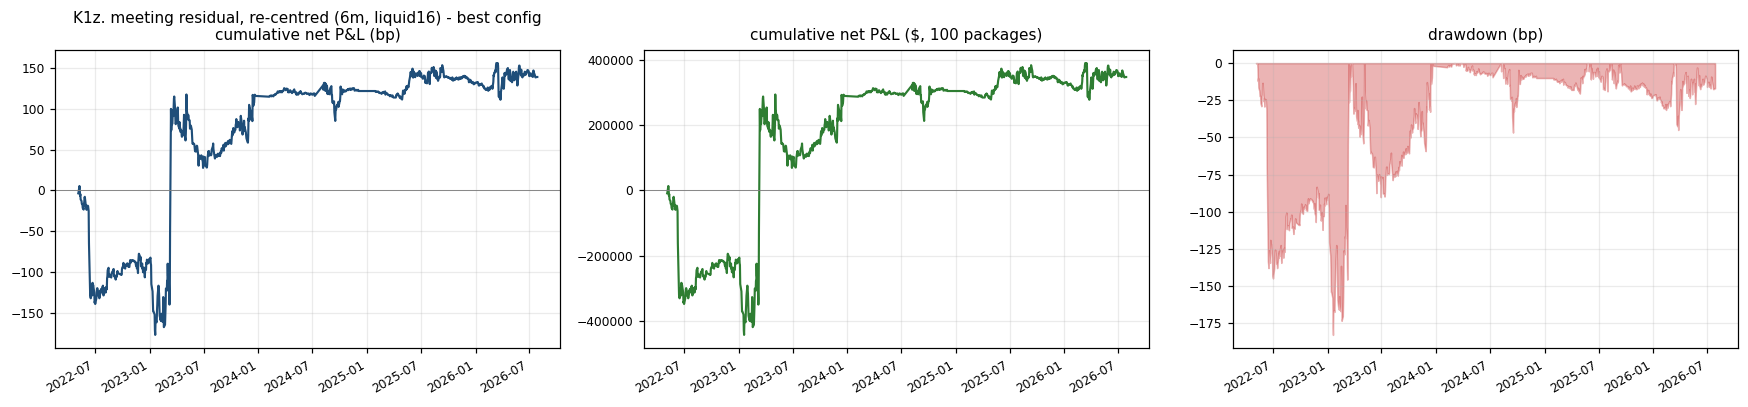


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp   net_usd    exit_reason
M22-Z22-M23   -1  2022-05-03 2022-05-04 2022-06-14    28  2.700      77.0     164.50    -87.50      2.0  -89.50 -223750.0       max_hold
H23-U23-H24    1  2022-05-13 2022-05-16 2022-08-16    63 -2.586      14.0       9.00     -5.00      2.0   -7.00  -17500.0       max_hold
U22-H23-U23   -1  2022-05-20 2022-05-23 2022-08-23    63  3.184      76.5      82.00     -5.50      2.0   -7.50  -18750.0       max_hold
Z23-M24-Z24   -1  2022-06-13 2022-06-14 2022-08-30    53  2.718      -6.0     -17.50     11.50      2.0    9.50   23750.0 mean_reversion
Z22-M23-Z23    1  2022-06-14 2022-06-15 2022-09-15    63 -4.083      42.5      40.50     -2.00      2.0   -4.00  -10000.0       max_hold
U24-H25-U25    1  2022-06-14 2022-06-15 2022-08-30    52 -2.831      -4.5      -5.50     -1.00      2.0   -3.00   -7500.0 mean_reversion
Z24-M25-Z25   

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0        85    41.459     0.412       1.641        139.50   0.289
band        95    33.126     0.400       0.379         36.00   0.085
  t5       239     4.983     0.213      -1.647       -393.75  -2.404
 t10       173     9.971     0.260      -1.594       -275.75  -1.344
 t21       122    20.885     0.344      -0.307        -37.50  -0.149
 t42        88    41.523     0.386      -2.287       -201.25  -0.611

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 85         309.5       3.641     0.635       773750.0
           0.5 85         267.0       3.141     0.529       667500.0
           1.0 85         224.5       2.641     0.494       561250.0
           1.5 85         182.0       2.141     0.435       455000.0
           2.0 85         139.5       1.641     0.412       348750.0
           2.5 85          97.0       1.141     0

K1z. meeting residual, re-centred (6m, liquid16) - MEDIAN config (the anti-selection control)  |  momentum|z2.0|t21|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   273   skipped    0   hit 26%   avg -1.771bp   avg hold 20.8d
  total    -483.50bp   $   -1,208,750   gross +62.50bp
  daily-MTM Sharpe -1.28   maxDD -563.00bp ($-1,407,500)   worst trade -38.50bp
  t(trade) -2.87   NW t(daily) -2.61   non-overlap SR -0.14   DSR p=0.000 over 72 trials

  LEAGUE ROW  K1z. meeting residual, re-centred (6m, liquid16) / best-config: SELECTION-ARTIFACT  (taker +139.50bp, maker +309.50bp, DSR p=0.000)

  LEAGUE ROW  K1z. meeting residual, re-centred (6m, liquid16) / median-config: MARGINAL-maker-only  (taker -483.50bp, maker +62.50bp, DSR p=0.000)


In [23]:
def k1z_6(L, window):
    return zscore_signal(mres6, window=window)


out_k1z_6 = K.run_family("K1z. meeting residual, re-centred (6m, liquid16)",
                         lab=lab6, signal_fn=k1z_6, grid_spec=GRID, params=PARAMS,
                         base=BASE, cls="kink",
                         note="full trailing z-score: throws the model's zero away", exits=EXITS)


### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -496.88bp | IQR [-657.38, -322.19] | 0% net-positive | best -44.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    120      2.5        t21      fade       159     0.327      -0.280        -44.50      -111250.0  -0.137    -140.50
    250      2.0        t42      fade       153     0.301      -0.307        -47.00      -117500.0  -0.066    -228.00
    250      2.5         z0      fade        94     0.383      -0.500        -47.00      -117500.0  -0.097    -193.50
     60      2.5         z0  momentum       173     0.260      -0.452        -78.25      -195625.0  -0.145    -263.50
    250      2.5        t42      fade        98     0.276      -0.827        -81.00      -202500.0  -0.126    -316.75
     60      2.5        t42  momentum       157     0.318      -0.709       -111.25      -278125.0  -0.198    -264.50
    250      

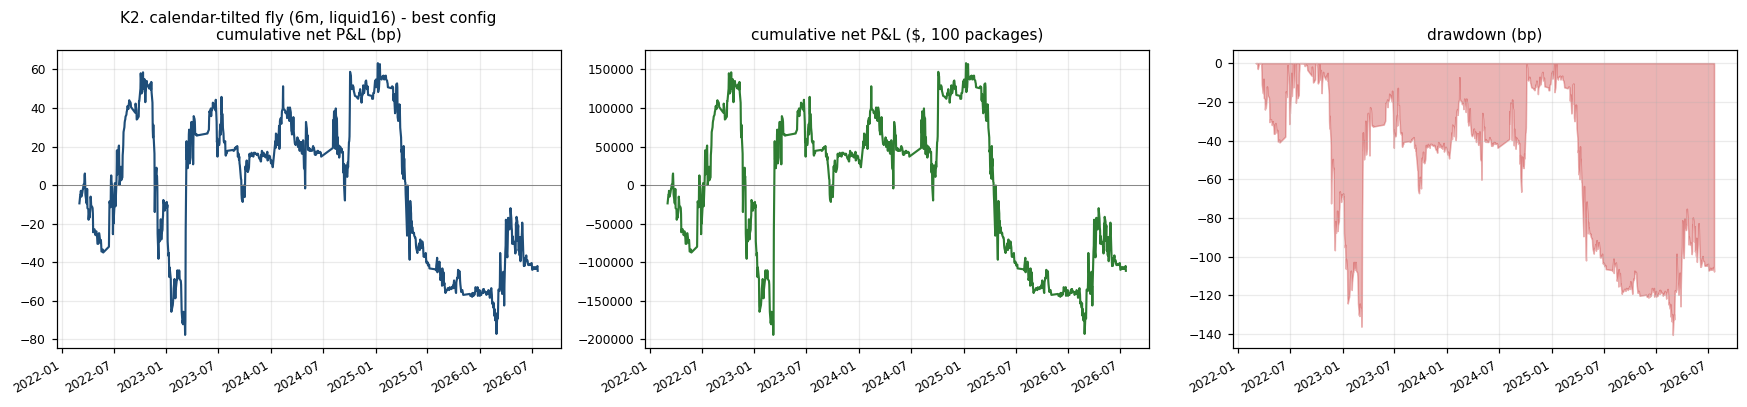


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
U23-H24-U24    1  2022-03-02 2022-03-03 2022-04-01    21 -2.729     -0.50      -3.50     -3.00      2.0   -5.00 -12500.0        time
Z23-M24-Z24    1  2022-03-02 2022-03-03 2022-04-01    21 -2.597    -13.00      -6.00      7.00      2.0    5.00  12500.0        time
Z24-M25-Z25    1  2022-03-04 2022-03-07 2022-04-05    21 -2.563     -5.50      -4.50      1.00      2.0   -1.00  -2500.0        time
H23-U23-H24   -1  2022-03-14 2022-03-15 2022-04-13    21  2.537     34.00      38.00     -4.00      2.0   -6.00 -15000.0        time
M22-Z22-M23   -1  2022-03-21 2022-03-22 2022-04-21    21  2.537     54.50      69.00    -14.50      2.0  -16.50 -41250.0        time
U23-H24-U24    1  2022-04-13 2022-04-14 2022-05-16    21 -2.757    -11.00      -9.50      1.50      2.0   -0.50  -1250.0        time
M23-Z23-M24    1  2022-04-26 2022-04-27 20

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       126    38.024     0.365      -2.565       -323.25  -0.718
band       128    32.406     0.344      -2.674       -342.25  -0.869
  t5       272     4.996     0.191      -1.800       -489.50  -2.654
 t10       211     9.938     0.275      -1.573       -332.00  -1.268
 t21       159    20.767     0.327      -0.280        -44.50  -0.137
 t42       122    41.221     0.311      -1.830       -223.25  -0.575

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 159         273.5        1.72     0.553       683750.0
           0.5 159         194.0        1.22     0.497       485000.0
           1.0 159         114.5        0.72     0.415       286250.0
           1.5 159          35.0        0.22     0.377        87500.0
           2.0 159         -44.5       -0.28     0.327      -111250.0
           2.5 159        -124.0       -0.7


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0       159           273.5         -44.5      -0.280     0.327  -0.137     -140.5      20.8          False             False
         belly       1            1            0.5       159           764.0         684.5       4.305     0.509   0.644     -366.5      20.8           True              True
belly_vs_front       2            2            1.0       159            -1.5        -160.5      -1.009     0.403  -0.446     -204.5      20.8          False             False
 belly_vs_back       2            2            1.0       159           275.0         116.0       0.730     0.428   0.473      -90.5      20.8           True              True
  -> SHADOWED - a simpler instrument beats the fly o

In [24]:
def k2_6(L, window):
    return zscore_signal(tilt6, window=window)


out_k2_6 = K.run_family("K2. calendar-tilted fly (6m, liquid16)", lab=lab6,
                        signal_fn=k2_6, grid_spec=GRID, params=PARAMS, base=BASE,
                        cls="kink", note="one degree of freedom, nothing fitted", exits=EXITS)

## 8. K4 — splitting on calendar symmetry

The sharpest form of the brief's question: *is the fade only real when the
calendar is not creating the kink?* The condition is `asym == 0` — the two
halves of the fly span the same integer number of meetings — applied at entry
only, because forcing an exit on a gate that fails later is a look-ahead exit.

**It is a static partition of keys, not a time-varying gate, and that changes
how it reads.** A key's legs are three fixed contracts, so the number of
meetings between their IMM start dates never changes over the key's life:
`asym` is constant per key by construction. So K4 and K4b split the *universe*
into two disjoint sets of butterflies, and any difference between them is
confounded with whatever else differs about those contracts — how many there
are, where they sit on the strip, and how far they move. The cell below
reports the pond for each side so that confound is visible rather than
assumed away.

asym takes 1 distinct value(s) within a key (1 == constant per key, i.e. a static partition)
  symmetric keys: 14 of 30   asymmetric keys: 16
  symmetric cells: 18.8%; gate keeps 18.8%

  pond size on each side of the partition (h=21, all cells, no signal):
         signal  horizon     n  mean_abs_bp  selectivity  median_abs_bp  p90_abs_bp  oracle_net_bp  p_beat_cost  mean_bp  sd_bp
  unconditional       21 13158        5.103        1.000            2.0        13.5          3.103        0.516    0.515  9.373
 symmetric keys       21  6183        6.478        1.269            3.0        17.0          4.478        0.600    0.835 11.248
asymmetric keys       21  6975        3.885        0.761            1.5        10.0          1.885        0.442    0.230  7.308

### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -240.88bp | IQR [-335.62, -135.56] | 8% net-positive | best +101.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.5        t42      fade        47     0.340       2.154        101.25       253125.0   0.216    -133.75
    250      2.0        t42      fade        72     0.375       0.931         67.00       167500.0   0.129    -199.25
    250      2.5        t21      fade        69     0.391       0.638         44.00       110000.0   0.113    -165.75
     60      2.0        t42  momentum       104     0.394       0.373         38.75        96875.0   0.073    -279.25
    120      2.5        t21      fade        77     0.429       0.500         38.50        96250.0   0.184     -97.75
    250      2.0         z0      fade        67     0.373       0.340         22.75        56875.0   0.046    -193.75
    120     

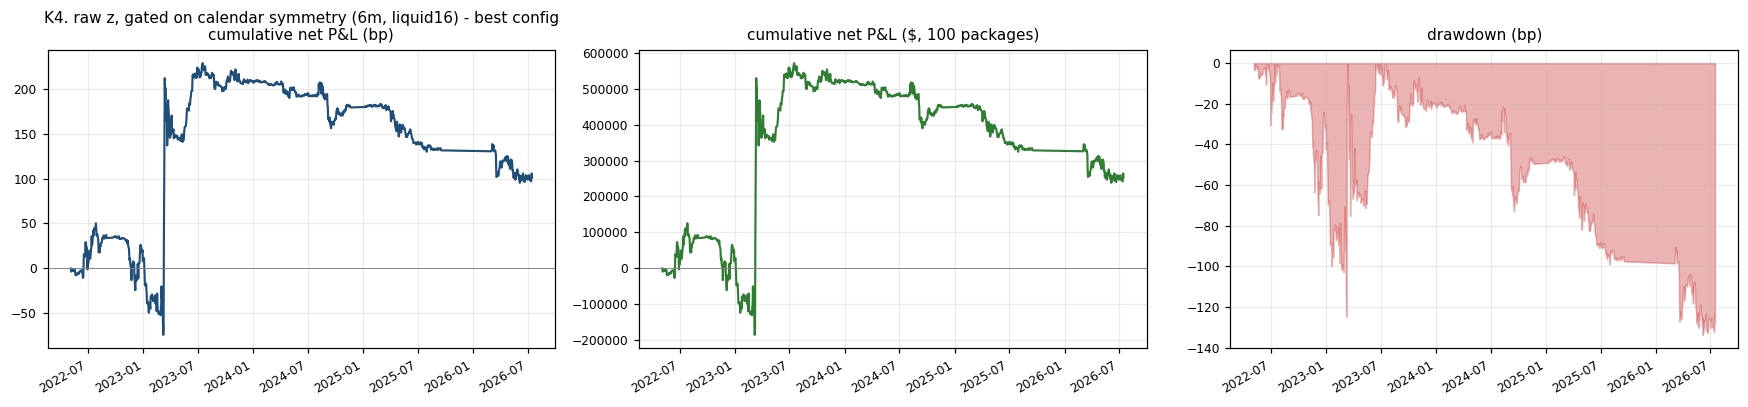


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
M23-Z23-M24    1  2022-05-02 2022-05-03 2022-07-05    42 -2.515       1.0      -15.0     -16.0      2.0   -18.0 -45000.0        time
U22-H23-U23   -1  2022-06-13 2022-06-14 2022-08-15    42  3.063     106.5       79.0      27.5      2.0    25.5  63750.0        time
U24-H25-U25    1  2022-06-17 2022-06-21 2022-08-19    42 -2.889      -5.0       -6.5      -1.5      2.0    -3.5  -8750.0        time
H23-U23-H24    1  2022-06-29 2022-06-30 2022-08-30    42 -2.673     -12.0       20.0      32.0      2.0    30.0  75000.0        time
H24-U24-H25    1  2022-07-01 2022-07-05 2022-09-01    42 -2.662     -13.5      -12.0       1.5      2.0    -0.5  -1250.0        time
H25-U25-H26    1  2022-09-21 2022-09-22 2022-11-21    42 -2.530      -6.5      -11.5      -5.0      2.0    -7.0 -17500.0        time
Z22-M23-Z23   -1  2022-11-03 2022-11-04 20


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        47           195.2         101.2       2.154     0.340   0.216     -133.8      40.4          False             False
         belly       1            1            0.5        47           253.0         229.5       4.883     0.426   0.307     -278.0      40.4           True              True
belly_vs_front       2            2            1.0        47            90.8          43.8       0.931     0.447   0.106     -192.3      40.4          False             False
 belly_vs_back       2            2            1.0        47           104.5          57.5       1.223     0.511   0.228      -93.5      40.4          False              True
  -> SHADOWED - a simpler instrument beats the fly o

In [25]:
lab6_sym = dict(lab6)
sym = (lab6["asym"].reindex(index=lab6["levels"].index,
                            columns=lab6["levels"].columns) == 0)
lab6_sym["gate"] = lab6["gate"] & sym.fillna(False)
per_key_asym = lab6["asym"].nunique(dropna=True)
print(f"asym takes {int(per_key_asym.max())} distinct value(s) within a key "
      f"(1 == constant per key, i.e. a static partition)")
sym_keys = [c for c in sym.columns if bool(sym[c].fillna(False).any())]
asym_keys = [c for c in sym.columns if c not in sym_keys]
print(f"  symmetric keys: {len(sym_keys)} of {sym.shape[1]}   "
      f"asymmetric keys: {len(asym_keys)}")
print(f"  symmetric cells: {100 * float(sym.mean().mean()):.1f}%; "
      f"gate keeps {100 * float(lab6_sym['gate'].mean().mean()):.1f}%")
_pond_split = K.oracle_table(
    lab6["levels"],
    {"symmetric keys": lab6["gate"] & sym.fillna(False),
     "asymmetric keys": lab6["gate"] & (~sym.fillna(True))},
    horizons=(21,), round_trip_bp=CONFIG["cost_bp"])
print("\n  pond size on each side of the partition (h=21, all cells, no signal):")
print(_pond_split.round(3).to_string(index=False))

out_k4 = K.run_family("K4. raw z, gated on calendar symmetry (6m, liquid16)",
                      lab=lab6_sym, signal_fn=k0, grid_spec=GRID, params=PARAMS,
                      base=BASE, cls="kink-gate",
                      note="entry only when asym == 0", exits=EXITS)


### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -272.75bp | IQR [-353.38, -166.69] | 1% net-positive | best +32.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     60      2.5        t42  momentum        80     0.312       0.403         32.25        80625.0   0.144    -107.50
    120      2.5         z0  momentum        62     0.290      -0.060         -3.75        -9375.0  -0.017    -178.00
    250      2.5        t42  momentum        52     0.346      -0.812        -42.25      -105625.0  -0.212    -103.00
     60      2.5         z0  momentum        90     0.267      -0.536        -48.25      -120625.0  -0.189    -172.75
    120      2.5        t42  momentum        63     0.317      -0.960        -60.50      -151250.0  -0.323    -125.00
    250      2.5         z0      fade        46     0.283      -1.576        -72.50      -181250.0  -0.346    -103.00
    120      

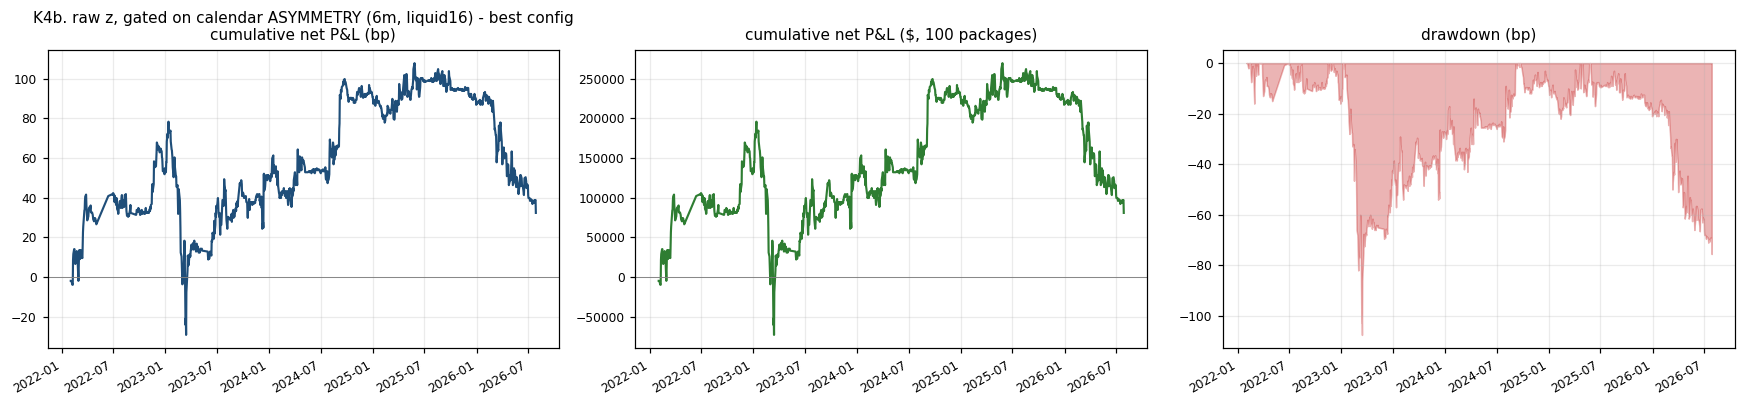


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
M22-Z22-M23    1  2022-01-31 2022-02-01 2022-04-01    42  2.634     19.00       64.0     45.00      2.0   43.00 107500.0        time
M24-Z24-M25   -1  2022-01-31 2022-02-01 2022-04-01    42 -2.665      1.50        7.5     -6.00      2.0   -8.00 -20000.0        time
Z24-M25-Z25   -1  2022-02-11 2022-02-14 2022-04-14    42 -3.225     -5.00       -4.5     -0.50      2.0   -2.50  -6250.0        time
Z23-M24-Z24   -1  2022-03-02 2022-03-03 2022-05-03    42 -2.593    -13.00       -9.0     -4.00      2.0   -6.00 -15000.0        time
M22-Z22-M23    1  2022-06-10 2022-06-13 2022-06-14     1  2.823    148.25      164.5     16.25      2.0   14.25  35625.0        time
Z24-M25-Z25   -1  2022-06-27 2022-06-28 2022-08-26    42 -2.854     -7.00       -4.5     -2.50      2.0   -4.50 -11250.0        time
M24-Z24-M25   -1  2022-07-01 2022-07-05 20


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        80           192.2          32.2       0.403     0.312   0.144     -107.5      40.5          False             False
         belly       1            1            0.5        80           170.0         130.0       1.625     0.512   0.115     -468.0      40.5           True             False
belly_vs_front       2            2            1.0        80           354.8         274.8       3.434     0.575   0.801     -145.0      40.5           True              True
 belly_vs_back       2            2            1.0        80          -162.5        -242.5      -3.031     0.312  -1.029     -239.5      40.5          False             False
  -> SHADOWED - a simpler instrument beats the fly o

In [26]:
lab6_asym = dict(lab6)
lab6_asym["gate"] = lab6["gate"] & (~sym.fillna(True))
out_k4b = K.run_family("K4b. raw z, gated on calendar ASYMMETRY (6m, liquid16)",
                       lab=lab6_asym, signal_fn=k0, grid_spec=GRID, params=PARAMS,
                       base=BASE, cls="kink-gate",
                       note="the complement -- if the calendar story is right "
                            "this is the one that should lose", exits=EXITS)

### 8a. The head-to-head

This is the only test in the notebook whose result **supports** the calendar
story, so it gets stated on its own rather than buried in the sign table. The
prediction is specific: fading the raw fly should work *less badly* on the
butterflies whose two halves span the same number of meetings.

Read it against the pond table above. If the symmetric keys simply move
further, the whole gap is move size and the calendar has explained nothing.

In [27]:
g4, g4b = out_k4["grid"], out_k4b["grid"]
cmp4 = pd.DataFrame({
    "asym == 0 (calendar symmetric)": [
        len(g4), g4["total_net_bp"].median(),
        g4[g4["direction"] == "fade"]["total_net_bp"].median(),
        g4[g4["direction"] == "momentum"]["total_net_bp"].median(),
        g4["total_net_bp"].max(), float((g4["total_net_bp"] > 0).mean()),
        g4["n_trades"].median()],
    "asym != 0 (calendar asymmetric)": [
        len(g4b), g4b["total_net_bp"].median(),
        g4b[g4b["direction"] == "fade"]["total_net_bp"].median(),
        g4b[g4b["direction"] == "momentum"]["total_net_bp"].median(),
        g4b["total_net_bp"].max(), float((g4b["total_net_bp"] > 0).mean()),
        g4b["n_trades"].median()],
}, index=["n_configs", "grid_median_bp", "fade_median_bp", "momentum_median_bp",
          "best_net_bp", "pct_positive", "median_trades"])
print("K4 vs K4b — the same raw-fly fade, split on whether the calendar is "
      "symmetric")
print(cmp4.round(1).to_string())
sym_fade = float(g4[g4["direction"] == "fade"]["total_net_bp"].median())
asym_fade = float(g4b[g4b["direction"] == "fade"]["total_net_bp"].median())
sym_wins = (float(g4[g4["direction"] == "fade"]["total_net_bp"].median())
            > float(g4[g4["direction"] == "momentum"]["total_net_bp"].median()))
asym_wins = (float(g4b[g4b["direction"] == "fade"]["total_net_bp"].median())
             > float(g4b[g4b["direction"] == "momentum"]["total_net_bp"].median()))
print(f"\n  fade median: symmetric {sym_fade:+.1f}bp vs asymmetric "
      f"{asym_fade:+.1f}bp   (per trade, normalised by median trade count: "
      f"{sym_fade / max(float(g4['n_trades'].median()), 1):+.3f} vs "
      f"{asym_fade / max(float(g4b['n_trades'].median()), 1):+.3f} bp)")
print(f"  fade is the winning SIGN on symmetric keys: {sym_wins};  "
      f"on asymmetric keys: {asym_wins}")
_ps = _pond_split.set_index("signal")
_sym_pond = float(_ps.loc["symmetric keys", "mean_abs_bp"])
_asym_pond = float(_ps.loc["asymmetric keys", "mean_abs_bp"])
_pond_ratio = _sym_pond / _asym_pond
_pnl_ratio = abs(asym_fade / max(float(g4b["n_trades"].median()), 1)) / \
    abs(sym_fade / max(float(g4["n_trades"].median()), 1))
print(f"""
  CONFOUND CHECK. This is a STATIC partition of {len(sym_keys)} keys against {len(asym_keys)}, not a
  day-by-day gate, so before reading it as a calendar effect it has to survive
  the obvious alternative: that the symmetric bucket simply contains
  bigger-moving flies.

    mean |21d move|      symmetric {_sym_pond:5.2f}bp   asymmetric {_asym_pond:5.2f}bp   ratio {_pond_ratio:.2f}x
    loss per trade       symmetric {abs(sym_fade / max(float(g4['n_trades'].median()), 1)):5.2f}bp   asymmetric {abs(asym_fade / max(float(g4b['n_trades'].median()), 1)):5.2f}bp   ratio {_pnl_ratio:.2f}x

  A fixed 2.0bp round trip is a SMALLER fraction of a bigger move, so a bucket
  that moves {_pond_ratio:.2f}x further loses less per trade for reasons that have nothing to
  do with the Fed. The two ratios are {_pond_ratio:.2f} and {_pnl_ratio:.2f}: {'the pond explains essentially the whole gap' if abs(_pond_ratio - _pnl_ratio) < 0.35 else 'the pond does NOT fully explain the gap'}.

  VERDICT ON THE LAST PIECE OF SUPPORT: {'the symmetry split is a move-size effect wearing a calendar label.' if abs(_pond_ratio - _pnl_ratio) < 0.35 else 'part of the split survives the move-size control and is worth another look.'}
  Both sides lose money at 2.0bp either way.""")
cmp4.to_csv(K.DATA_DIR / "symmetry_gate.csv")
_pond_split.to_csv(K.DATA_DIR / "symmetry_pond.csv", index=False)

K4 vs K4b — the same raw-fly fade, split on whether the calendar is symmetric
                    asym == 0 (calendar symmetric)  asym != 0 (calendar asymmetric)
n_configs                                     72.0                             72.0
grid_median_bp                              -240.9                           -272.8
fade_median_bp                              -153.1                           -308.0
momentum_median_bp                          -296.4                           -242.8
best_net_bp                                  101.2                             32.2
pct_positive                                   0.1                              0.0
median_trades                                104.5                            120.0

  fade median: symmetric -153.1bp vs asymmetric -308.0bp   (per trade, normalised by median trade count: -1.465 vs -2.567 bp)
  fade is the winning SIGN on symmetric keys: True;  on asymmetric keys: False

  CONFOUND CHECK. This is a STATIC partitio

## 9. K3 — cross-sectional fade

The prior work's one genuinely positive result was the naive within-bucket
`ls_fade` (IR ≈ +1.35 gross, non-overlapping Sharpe ≈ +1.97) — gross of costs,
one regime, one year. Reproduced here through the same engine, so it pays the
same per-contract round trip as everything else, on the raw fly and on the
meeting residual.


### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -111.62bp | IQR [-262.62, -27.12] | 7% net-positive | best +100.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.0        t42  momentum        37     0.270       2.716        100.50       251250.0   0.556     -84.00
    250      2.0         z0  momentum        47     0.255       0.755         35.50        88750.0   0.189    -107.25
    120      2.5         z0  momentum        10     0.200       2.900         29.00        72500.0   1.026     -23.50
    120      2.5        t42  momentum         8     0.250       2.250         18.00        45000.0   0.515     -22.75
    250      2.5         z0  momentum        11     0.182       1.227         13.50        33750.0   0.327     -39.50
    250      2.5        t21      fade        13     0.154      -0.212         -2.75        -6875.0  -0.083     -47.25
    120      

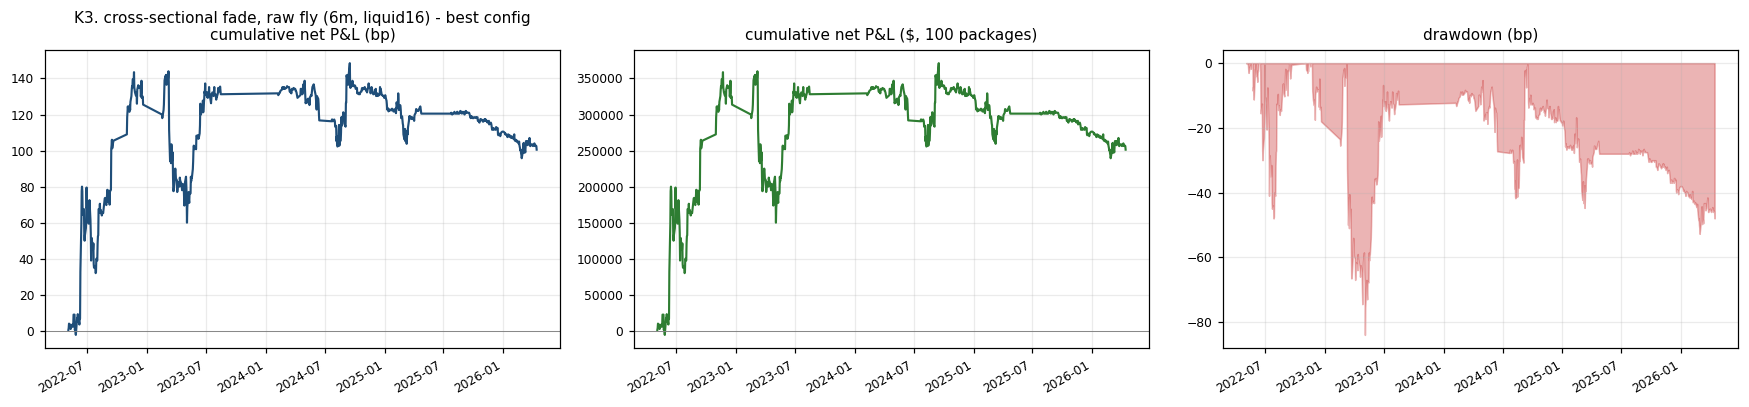


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
M23-Z23-M24   -1  2022-05-02 2022-05-03 2022-07-05    42 -2.161       1.0     -15.00     16.00      2.0   14.00  35000.0        time
M22-Z22-M23    1  2022-05-16 2022-05-17 2022-06-14    19  2.041      96.0     164.50     68.50      2.0   66.50 166250.0        time
U22-H23-U23    1  2022-06-15 2022-06-16 2022-08-17    42  2.169      93.0      82.25    -10.75      2.0  -12.75 -31875.0        time
H25-U25-H26    1  2022-07-14 2022-07-15 2022-09-14    42  2.187      -4.0      -6.50     -2.50      2.0   -4.50 -11250.0        time
U22-H23-U23    1  2022-08-18 2022-08-19 2022-09-20    21  2.500      76.5     120.75     44.25      2.0   42.25 105625.0        time
Z22-M23-Z23    1  2022-10-27 2022-10-28 2022-12-20    36  2.332      60.5      82.50     22.00      2.0   20.00  50000.0        time
U23-H24-U24    1  2023-02-14 2023-02-15 20


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        37           174.5         100.5       2.716     0.270   0.556      -84.0      39.1          False             False
         belly       1            1            0.5        37           103.0          84.5       2.284     0.541   0.146     -356.0      39.1          False             False
belly_vs_front       2            2            1.0        37           205.0         168.0       4.541     0.459   0.856      -72.5      39.1           True              True
 belly_vs_back       2            2            1.0        37           -30.5         -67.5      -1.824     0.378  -0.470     -102.5      39.1          False             False
  -> SHADOWED - a simpler instrument beats the fly o

In [28]:
# `xsection_signal` buckets by a per-COLUMN label, and a key's pack colour
# ROLLS with its constant-maturity slot -- a fly born in the blues arrives in
# the whites four years later. Labelling columns by the pack a key was born in
# is prior-lab bug 11 and would put most of the strip in one bucket. The
# `window` argument already converts each key to its own trailing z-score before
# the cross-section is taken, so the ranking is over dislocation in units of
# each key's own volatility and is scale-free across maturities. That is what
# the bucketing was there to achieve, so a single bucket is the correct choice
# here rather than a wrong one.
groups6 = None


def k3_raw(L, window):
    return xsection_signal(L, groups=groups6, method="zscore", window=window)


out_k3 = K.run_family("K3. cross-sectional fade, raw fly (6m, liquid16)",
                      lab=lab6, signal_fn=k3_raw, grid_spec=GRID, params=PARAMS,
                      base=BASE, cls="xsection",
                      note="rank each key's own trailing dislocation across the "
                           "strip", exits=EXITS)


### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -142.00bp | IQR [-364.44, -24.75] | 12% net-positive | best +45.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.5         z0      fade         2      1.00      22.750         45.50       113750.0   3.692       -6.0
     60      2.5        t42  momentum         5      0.40       8.550         42.75       106875.0   1.301      -34.0
    250      2.5        t21      fade         2      0.50      18.500         37.00        92500.0   4.879       -6.0
    120      2.5        t42  momentum         4      0.25       8.938         35.75        89375.0   1.414      -29.5
    250      2.5        t42      fade         2      1.00      14.750         29.50        73750.0   1.869      -23.5
    120      2.5         z0  momentum         4      0.25       5.375         21.50        53750.0   0.945      -29.5
    120      

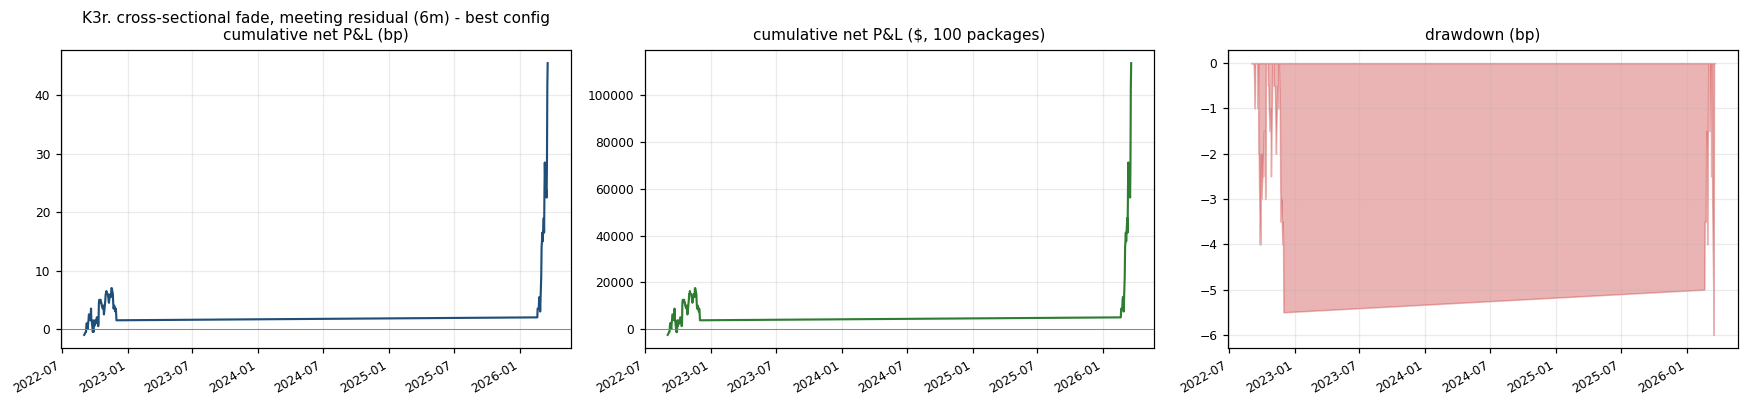


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
Z24-M25-Z25   -1  2022-08-31 2022-09-01 2022-12-01    63  2.543      -5.5       -9.0       3.5      2.0     1.5   3750.0       max_hold
M26-Z26-M27    1  2026-02-17 2026-02-18 2026-03-20    22 -2.732     -31.0       15.0      46.0      2.0    44.0 110000.0 mean_reversion

  exit comparison:
exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0         2      42.5       1.0       22.75          45.5   3.692
band         2      29.5       1.0       14.50          29.0   4.258
  t5         2       5.0       0.5        0.50           1.0   1.410
 t10         2      10.0       1.0        6.00          12.0   4.833
 t21         2      21.0       0.5       18.50          37.0   4.879
 t42         2      42.0       1.0       14.75          29.5   1.869

  cost curve (round-trip bp charged on the package):
 round_t


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0         2            49.5          45.5       22.75       1.0   3.692       -6.0      42.5          False             False
         belly       1            1            0.5         2            79.0          78.0       39.00       1.0   1.498     -102.5      42.5           True             False
belly_vs_front       2            2            1.0         2            44.5          42.5       21.25       1.0   2.832      -15.5      42.5          False             False
 belly_vs_back       2            2            1.0         2             5.0           3.0        1.50       0.5   0.370       -9.0      42.5          False             False
  -> SHADOWED - a simpler instrument beats the fly o

In [29]:
_mres6_pack = mres6


def k3_resid(L, window):
    return xsection_signal(_mres6_pack, groups=groups6, method="zscore",
                           window=window)


out_k3r = K.run_family("K3r. cross-sectional fade, meeting residual (6m)",
                       lab=lab6, signal_fn=k3_resid, grid_spec=GRID,
                       params=PARAMS, base=BASE, cls="xsection",
                       note="same, on the calendar-adjusted level", exits=EXITS)

## 10. Front slots only, attributed by date

A key's constant-maturity slot **rolls** — a fly born at slot 15 arrives at
slot 2 four years later — so restricting by a key's birth slot tags every key
with the wrong bucket (bug 11 of the prior lab). The restriction is applied
through the `(date, key)` gate instead.

front-slot cells (cm_slot <= 5): 10.0%

### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -170.00bp | IQR [-291.38, -75.94] | 14% net-positive | best +211.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     60      2.5         z0      fade        58     0.569       3.638        211.00       527500.0   0.425    -154.50
    120      2.5         z0      fade        46     0.543       3.250        149.50       373750.0   0.353    -160.75
     60      1.5         z0      fade        80     0.562       0.762         61.00       152500.0   0.135    -147.50
     60      2.0         z0      fade        63     0.540       0.869         54.75       136875.0   0.125    -205.00
     60      2.0        t42      fade        68     0.485       0.676         46.00       115000.0   0.102    -217.50
    120      1.5         z0      fade        62     0.548       0.673         41.75       104375.0   0.102    -175.00
    120     

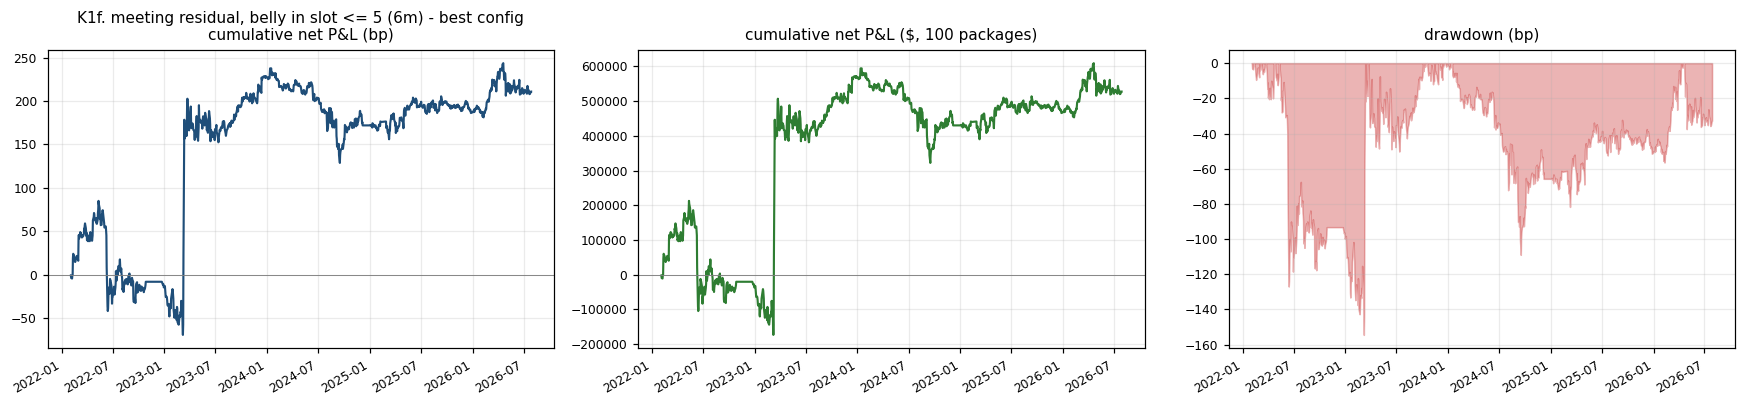


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp   net_usd    exit_reason
U22-H23-U23   -1  2022-01-31 2022-02-01 2022-02-14     9  2.669      21.5      30.50     -9.00      2.0  -11.00  -27500.0 mean_reversion
M22-Z22-M23    1  2022-02-02 2022-02-03 2022-03-28    36 -2.551      17.5      66.00     48.50      2.0   46.50  116250.0 mean_reversion
H22-U22-H23    1  2022-02-04 2022-02-07 2022-02-11     4 -2.565      25.0      48.00     23.00      2.0   21.00   52500.0 mean_reversion
U22-H23-U23   -1  2022-02-24 2022-02-25 2022-04-25    40  2.983      35.0      53.50    -18.50      2.0  -20.50  -51250.0 mean_reversion
H22-U22-H23    1  2022-02-28 2022-03-01 2022-03-15    10 -2.790      15.5      44.00     28.50      2.0   26.50   66250.0       max_hold
Z22-M23-Z23   -1  2022-03-16 2022-03-17 2022-05-16    41  4.181      48.5      41.50      7.00      2.0    5.00   12500.0 mean_reversion
M22-Z22-M23   


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        58           327.0         211.0       3.638     0.569   0.425     -154.5      35.9          False             False
         belly       1            1            0.5        58            52.0          23.0       0.397     0.517   0.025     -360.5      35.9          False             False
belly_vs_front       2            2            1.0        58           180.5         122.5       2.112     0.500   0.307     -154.0      35.9          False             False
 belly_vs_back       2            2            1.0        58           146.5          88.5       1.526     0.517   0.286     -124.5      35.9          False             False
  -> fly beats every linear shadow on net bp
K1f. me

In [30]:
lab6_front = dict(lab6)
front_mask = (lab6["cm_slot_at"].reindex(index=lab6["levels"].index,
                                         columns=lab6["levels"].columns)
              <= CONFIG["front_slot_cut"])
lab6_front["gate"] = lab6["gate"] & front_mask.fillna(False)
print(f"front-slot cells (cm_slot <= {CONFIG['front_slot_cut']}): "
      f"{100 * float(front_mask.fillna(False).mean().mean()):.1f}%")
out_front = K.run_family(
    f"K1f. meeting residual, belly in slot <= {CONFIG['front_slot_cut']} (6m)",
    lab=lab6_front, signal_fn=k1_6, grid_spec=GRID, params=PARAMS, base=BASE,
    cls="kink", note="where the liquidity and the dispersion both are", exits=EXITS)

In [31]:
per = K.per_slot_table(out_k1_6["result"], lab6)
if not per.empty:
    print("K1 (6m) net P&L by the CM slot each trade was ENTERED in:")
    print(per.round(3).to_string(index=False))

K1 (6m) net P&L by the CM slot each trade was ENTERED in:
 slot           cm  n   hit  avg_net_bp  total_net_bp  total_gross_bp  avg_hold  total_net_usd
  3.0       SFR135 18 0.611      -4.889        -88.00          -52.00    25.333      -220000.0
  4.0       SFR246 16 0.562      12.359        197.75          229.75    39.438       494375.0
  5.0       SFR357 19 0.526       2.289         43.50           81.50    36.842       108750.0
  6.0       SFR468 21 0.667       5.667        119.00          161.00    41.000       297500.0
  7.0       SFR579 17 0.412      -1.735        -29.50            4.50    43.294       -73750.0
  8.0   SFR-6-8-10 17 0.412       0.882         15.00           49.00    24.412        37500.0
  9.0   SFR-7-9-11 16 0.500       1.500         24.00           56.00    35.188        60000.0
 10.0  SFR-8-10-12 17 0.706       1.941         33.00           67.00    50.529        82500.0
 11.0  SFR-9-11-13 18 0.333      -0.556        -10.00           26.00    36.833       -

## 11. The long window — 2019+, which buys ZIRP and the hiking cycle

Nothing is believed on one window. `front8` restricts the back leg to slot 8
but starts in 2019, so it is the only window containing a full policy cycle.

34 flies x 1906 sessions, slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking

### GRID  (34 keys, 1906 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/72 configs


  50/72 configs


  72 configs | median -351.62bp | IQR [-554.88, -80.81] | 15% net-positive | best +242.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     60      2.5         z0      fade       119     0.471       2.038        242.50       606250.0   0.358    -130.00
    120      2.5         z0      fade        91     0.451       2.385        217.00       542500.0   0.358    -155.00
     60      1.5        t42      fade       153     0.418       1.337        204.50       511250.0   0.307    -211.50
    250      2.5         z0      fade        58     0.517       3.366        195.25       488125.0   0.370    -209.50
    250      1.5         z0      fade        93     0.516       1.949        181.25       453125.0   0.347    -207.50
    250      2.0         z0      fade        77     0.481       1.964        151.25       378125.0   0.311    -235.00
    120     

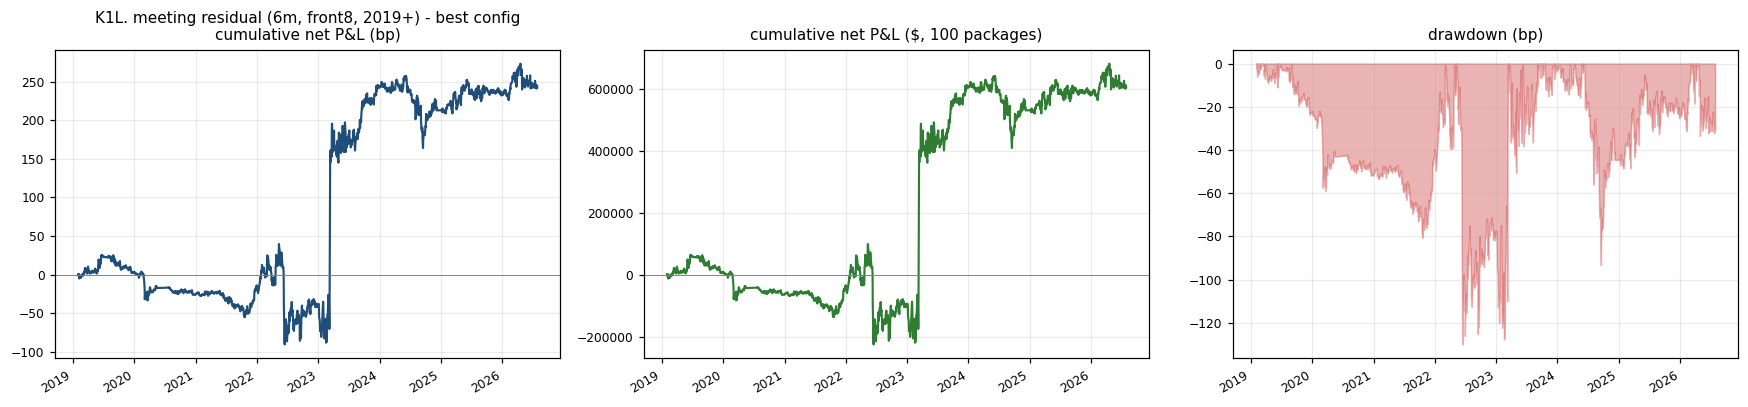


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
H19-U19-H20   -1  2019-01-30 2019-01-31 2019-03-19    32  4.826      9.00       3.50      5.50      2.0    3.50   8750.0 mean_reversion
Z19-M20-Z20    1  2019-01-30 2019-01-31 2019-04-02    42 -3.714     -5.00      -6.00     -1.00      2.0   -3.00  -7500.0 mean_reversion
U19-H20-U20    1  2019-01-30 2019-01-31 2019-02-21    14 -3.139     -3.00       0.50      3.50      2.0    1.50   3750.0 mean_reversion
M19-Z19-M20   -1  2019-01-30 2019-01-31 2019-05-02    63  3.275      4.00       0.00      4.00      2.0    2.00   5000.0       max_hold
H20-U20-H21    1  2019-04-16 2019-04-17 2019-06-03    31 -4.605     -7.50     -14.50     -7.00      2.0   -9.00 -22500.0 mean_reversion
U19-H20-U20   -1  2019-04-26 2019-04-29 2019-05-14    11  2.860     -2.00      -8.00      6.00      2.0    4.00  10000.0 mean_reversion
M19-Z19-M20   -1  201

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       119    34.496     0.471       2.038        242.50   0.358
band       126    30.032     0.460       0.677         85.25   0.149
  t5       443     4.928     0.280      -1.391       -616.25  -1.930
 t10       300     9.717     0.370      -0.588       -176.50  -0.470
 t21       189    19.825     0.392      -0.409        -77.25  -0.150
 t42       121    36.950     0.463      -0.432        -52.25  -0.096

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 119         480.5       4.038     0.597      1201250.0
           0.5 119         421.0       3.538     0.580      1052500.0
           1.0 119         361.5       3.038     0.546       903750.0
           1.5 119         302.0       2.538     0.487       755000.0
           2.0 119         242.5       2.038     0.471       606250.0
           2.5 119         183.0       1.53

K1L. meeting residual (6m, front8, 2019+) - MEDIAN config (the anti-selection control)  |  momentum|z1.5|t42|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  trades    87   skipped    0   hit 36%   avg -3.957bp   avg hold 37.1d
  total    -344.25bp   $     -860,625   gross -170.25bp
  daily-MTM Sharpe -0.73   maxDD -368.00bp ($-920,000)   worst trade -51.00bp
  t(trade) -1.65   NW t(daily) -1.88   non-overlap SR -0.17   DSR p=0.000 over 72 trials

  LEAGUE ROW  K1L. meeting residual (6m, front8, 2019+) / best-config: SELECTION-ARTIFACT  (taker +242.50bp, maker +480.50bp, DSR p=0.000)

  LEAGUE ROW  K1L. meeting residual (6m, front8, 2019+) / median-config: DEAD  (taker -344.25bp, maker -170.25bp, DSR p=0.000)


In [32]:
lab6_long = K.load_kink_lab("6m", CONFIG["long_window"], lam=CONFIG["lam"],
                            max_slot=CONFIG["max_slot"], contracts=contracts)
mres6_long = resid_fly(lab6_long, CONFIG["lam"])
print(f"{lab6_long['levels'].shape[1]} flies x {lab6_long['levels'].shape[0]} "
      f"sessions, {lab6_long['window_why']}")


def k1_long(L, window):
    return scale_only_zscore(mres6_long, window=window)


out_long = K.run_family("K1L. meeting residual (6m, front8, 2019+)",
                        lab=lab6_long, signal_fn=k1_long, grid_spec=GRID,
                        params=PARAMS, base=BASE, cls="kink",
                        note="the regime-rich window", exits=EXITS)


### GRID  (34 keys, 1906 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/72 configs


  50/72 configs


  72 configs | median -255.00bp | IQR [-385.31, -118.25] | 10% net-positive | best +237.75bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     60      2.5         z0  momentum        95     0.358       2.503        237.75       594375.0   0.432    -132.00
    250      2.5         z0  momentum        44     0.409       4.239        186.50       466250.0   0.465    -139.75
     60      2.0         z0  momentum       139     0.302       0.660         91.75       229375.0   0.128    -279.00
     60      2.5        t42  momentum        87     0.425       1.009         87.75       219375.0   0.152    -250.25
    250      2.0         z0  momentum        60     0.367       1.117         67.00       167500.0   0.111    -291.00
    120      2.5         z0  momentum        69     0.362       0.920         63.50       158750.0   0.132    -207.25
    250    

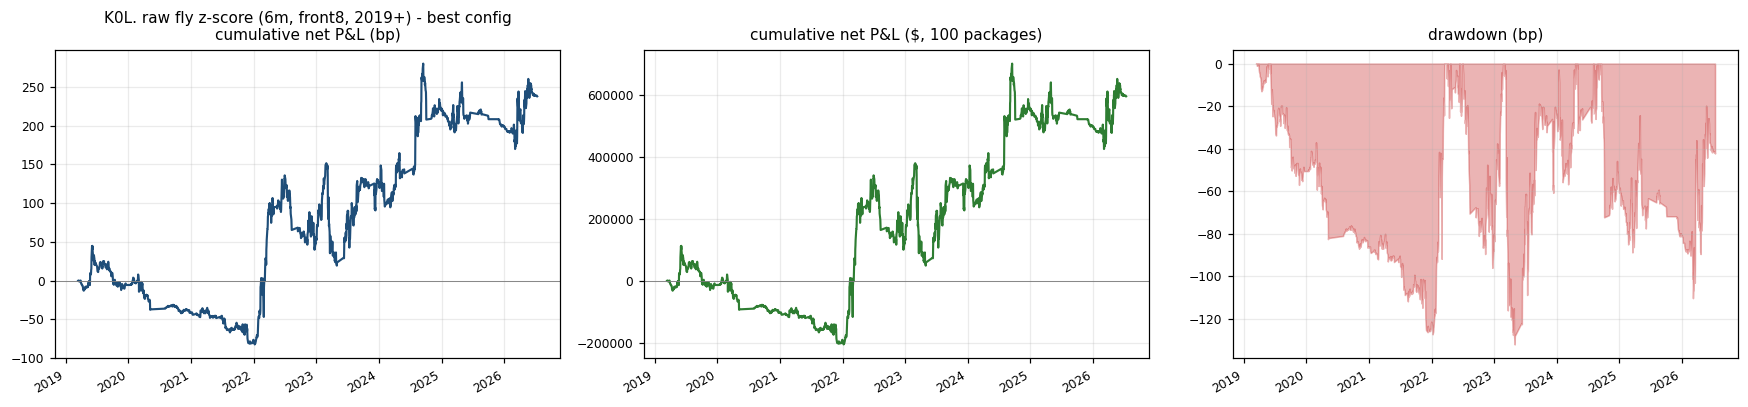


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
H19-U19-H20   -1  2019-03-12 2019-03-13 2019-03-19     4 -2.572       4.5       3.50      1.00      2.0   -1.00  -2500.0       max_hold
M19-Z19-M20   -1  2019-03-25 2019-03-26 2019-06-18    58 -3.151       0.5     -23.00     23.50      2.0   21.50  53750.0       max_hold
Z19-M20-Z20   -1  2019-03-27 2019-03-28 2019-04-15    12 -2.849     -11.0      -4.50     -6.50      2.0   -8.50 -21250.0 mean_reversion
U19-H20-U20   -1  2019-05-13 2019-05-14 2019-08-13    63 -2.808      -8.0     -26.00     18.00      2.0   16.00  40000.0       max_hold
Z19-M20-Z20   -1  2019-05-15 2019-05-16 2019-08-02    54 -2.816     -11.0     -14.50      3.50      2.0    1.50   3750.0 mean_reversion
H20-U20-H21   -1  2019-05-28 2019-05-29 2019-06-10     8 -2.921     -14.5      -8.50     -6.00      2.0   -8.00 -20000.0 mean_reversion
M20-Z20-M21    1  201


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        95           427.8         237.8       2.503     0.358   0.432     -132.0      33.8          False             False
         belly       1            1            0.5        95          1478.0        1430.5      15.058     0.537   0.937     -326.5      33.8           True              True
belly_vs_front       2            2            1.0        95           637.2         542.2       5.708     0.537   0.873     -159.5      33.8           True              True
 belly_vs_back       2            2            1.0        95          -209.5        -304.5      -3.205     0.316  -0.713     -392.0      33.8          False             False
  -> SHADOWED - a simpler instrument beats the fly o

In [33]:
out_k0_long = K.run_family("K0L. raw fly z-score (6m, front8, 2019+)",
                           lab=lab6_long, signal_fn=k0, grid_spec=GRID,
                           params=PARAMS, base=BASE, cls="kink",
                           note="control on the same window", exits=EXITS)

## 12. Sensitivity to the projected calendar

2028+ meeting dates do not exist yet. They are projected by a documented rule
and every projected row is flagged. This shifts the projection by a week in
each direction and reports how much the signal moves — rather than asking
anyone to take the projection on trust.

In [34]:
rows = []
base_sig = mres6
touched = lab6["calendar"].groupby("key")["proj_any"].any()
for shift in (-1, 0, 1):
    mt = fomc_decisions(datetime.date(2017, 1, 1), datetime.date(2032, 12, 31),
                        shift_weeks=shift)
    p = resid_fly(lab6, CONFIG["lam"], mt, f"shift{shift}")
    corr = pd.Series({c: base_sig[c].corr(p[c]) for c in base_sig.columns})
    # the median key never sees a projected meeting, so the median correlation
    # is 1.000 whatever the shift does. The binding number is the worst key,
    # and the worst key among those that DO reach past the published calendar.
    hit = [c for c in corr.index if bool(touched.get(c, False))]
    rows.append({"projection_shift_weeks": shift,
                 "resid_sd_bp": float(p.stack().std()),
                 "median_corr": float(corr.median()),
                 "min_corr": float(corr.min()),
                 "min_corr_projected_keys": float(corr[hit].min()) if hit else np.nan,
                 "n_keys_projected": len(hit)})
sens = pd.DataFrame(rows)
print(sens.round(4).to_string(index=False))
proj = lab6["resid_extras"]["proj_share"]
print(f"\n  share of each date's fitted jump magnitude on PROJECTED meetings: "
      f"median {proj.median():.3f}, p95 {proj.quantile(0.95):.3f}")
print(f"  structures whose span reaches a projected meeting: "
      f"{100 * float(lab6['calendar']['proj_any'].mean()):.1f}% of rows, "
      f"{int(touched.sum())} of {len(touched)} keys")
worst = float(sens.loc[sens["projection_shift_weeks"] != 0,
                       "min_corr_projected_keys"].min())
print(f"""
  READ THE min_corr COLUMN, NOT THE MEDIAN. The median key never reaches a
  projected meeting, so its correlation is 1.000 whatever the shift does -- the
  median is uninformative by construction. The binding number is the worst key
  among the {int(sens['n_keys_projected'].iloc[0])} that DO span a projected meeting, and it is {worst:+.3f}.

  So a single week of projection error DESTROYS the meeting residual on the
  back of the strip. That is a real limitation of K1 on deep keys, and it cuts
  the same way as everything else in this notebook: the part of the signal that
  depends on the meeting calendar is the part that is least reliable, while the
  headline rows (front8, and belly in slot <= 5) barely touch it. Section 4
  already showed the back of the strip cannot pay a 2.0bp round trip on move
  size alone, so nothing tradeable rests on it -- but any future work that
  reaches past the published calendar has to carry this number.""")

 projection_shift_weeks  resid_sd_bp  median_corr  min_corr  min_corr_projected_keys  n_keys_projected
                     -1       5.6610          1.0    0.9906                   0.9906                11
                      0       5.6611          1.0    1.0000                   1.0000                11
                      1       5.6611          1.0    0.9795                   0.9795                11

  share of each date's fitted jump magnitude on PROJECTED meetings: median 0.008, p95 0.382
  structures whose span reaches a projected meeting: 27.3% of rows, 11 of 30 keys

  READ THE min_corr COLUMN, NOT THE MEDIAN. The median key never reaches a
  projected meeting, so its correlation is 1.000 whatever the shift does -- the
  median is uninformative by construction. The binding number is the worst key
  among the 11 that DO span a projected meeting, and it is +0.980.

  So a single week of projection error DESTROYS the meeting residual on the
  back of the strip. That is a rea

## 13. Verdict

In [35]:
league = pd.read_csv(K.DATA_DIR / "league_table.csv")
print(f"LEAGUE TABLE — {len(league)} rows, taker = {K.TAKER_BP}bp per contract "
      f"round trip\n")
show = ["framework", "variant", "structure", "window", "n_trades", "hit_rate",
        "avg_net_bp", "total_gross_bp", "total_net_bp", "net_bp_maker",
        "net_bp_taker", "grid_median_net_bp", "dsr_prob", "nonoverlap_sharpe",
        "verdict"]
print(league.sort_values("total_net_bp", ascending=False)[
    [c for c in show if c in league.columns]].round(3).to_string(index=False))
league.sort_values("total_net_bp", ascending=False).to_csv(
    K.DATA_DIR / "league_table_sorted.csv", index=False)

LEAGUE TABLE — 28 rows, taker = 2.0bp per contract round trip

                                             framework       variant structure   window  n_trades  hit_rate  avg_net_bp  total_gross_bp  total_net_bp  net_bp_maker  net_bp_taker  grid_median_net_bp  dsr_prob  nonoverlap_sharpe               verdict
             K1L. meeting residual (6m, front8, 2019+)   best-config        6m   front8       119     0.471       2.038          480.50        242.50        480.50        242.50            -351.625     0.000             -0.119    SELECTION-ARTIFACT
              K0L. raw fly z-score (6m, front8, 2019+)   best-config        6m   front8        95     0.358       2.503          427.75        237.75        427.75        237.75            -255.000     0.037              0.019    SELECTION-ARTIFACT
        K1f. meeting residual, belly in slot <= 5 (6m)   best-config        6m liquid16        58     0.569       3.638          327.00        211.00        327.00        211.00            -

In [36]:
print("verdict distribution:")
print(league["verdict"].value_counts().to_string())
n = len(league)
print(f"\n  rows net positive GROSS               "
      f"{int((league['total_gross_bp'] > 0).sum())} / {n}")
print(f"  rows net positive at maker (0.0bp)    "
      f"{int((league['net_bp_maker'] > 0).sum())} / {n}")
print(f"  rows net positive at taker ({K.TAKER_BP}bp)   "
      f"{int((league['net_bp_taker'] > 0).sum())} / {n}")
print(f"  rows with a positive GRID MEDIAN      "
      f"{int((league['grid_median_net_bp'] > 0).sum())} / {n}")
print(f"  median DSR probability                "
      f"{league['dsr_prob'].median():.4f}   (threshold 0.5)")
print(f"  ALIVE                                 "
      f"{int((league['verdict'] == 'ALIVE').sum())}")
_n_fam = league["framework"].nunique()
print(f"""
  ONE CAVEAT ON THE DSR, IN THE DIRECTION THAT MATTERS. Each row is deflated by
  its OWN family's {int(league['n_trades'].notna().sum() and 72)} configs, but {_n_fam} families were searched -- most of them
  on the identical liquid16 level panel. The honest trial count is closer to
  {_n_fam} x 72 = {_n_fam * 72}, so every DSR printed here is TOO GENEROUS. It does not change a
  verdict, because the median is already {league['dsr_prob'].median():.4f}.""")

verdict distribution:
verdict
MARGINAL-maker-only      11
DEAD                      8
SELECTION-ARTIFACT        8
DEAD (too few trades)     1

  rows net positive GROSS               20 / 28
  rows net positive at maker (0.0bp)    20 / 28
  rows net positive at taker (2.0bp)   9 / 28
  rows with a positive GRID MEDIAN      0 / 28
  median DSR probability                0.0000   (threshold 0.5)
  ALIVE                                 0

  ONE CAVEAT ON THE DSR, IN THE DIRECTION THAT MATTERS. Each row is deflated by
  its OWN family's 72 configs, but 14 families were searched -- most of them
  on the identical liquid16 level panel. The honest trial count is closer to
  14 x 72 = 1008, so every DSR printed here is TOO GENEROUS. It does not change a
  verdict, because the median is already 0.0000.


In [37]:
signs = pd.read_csv(K.DATA_DIR / "sign_tests.csv")
w = signs.pivot_table(index="framework", columns="direction",
                      values="median_net_bp", aggfunc="first")
w["fade_wins"] = w.get("fade", np.nan) > w.get("momentum", np.nan)
print("SIGN TEST across every framework (median net bp of the whole sweep)")
print(w.round(1).to_string())
print(f"\n  fade beats momentum in {int(w['fade_wins'].sum())} of {len(w)} "
      f"frameworks -- mean reversion is the right DIRECTION; it is the cost and "
      f"the packaging that fail.")

SIGN TEST across every framework (median net bp of the whole sweep)
direction                                                fade  momentum  fade_wins
framework                                                                         
K0. raw fly z-score (3m, liquid16)                     -494.9    -576.6       True
K0. raw fly z-score (6m, liquid16)                     -447.9    -497.1       True
K0L. raw fly z-score (6m, front8, 2019+)               -359.8    -124.0      False
K1. meeting residual (3m, liquid16)                    -468.8    -902.1       True
K1. meeting residual (6m, liquid16)                    -287.8    -931.4       True
K1L. meeting residual (6m, front8, 2019+)               -79.6    -549.6       True
K1f. meeting residual, belly in slot <= 5 (6m)         -120.2    -233.9       True
K1z. meeting residual, re-centred (6m, liquid16)       -463.5    -485.0       True
K2. calendar-tilted fly (3m, liquid16)                 -503.1    -567.8       True
K2. calendar-tilted

In [38]:
shadows = pd.read_csv(K.DATA_DIR / "shadow_tests.csv")
beat = (shadows[shadows["instrument"] != "fly"]
        .groupby("framework")["beats_fly_net"].any())
print("LINEAR-SHADOW DECOMPOSITION — does a simpler instrument beat the fly?")
print(f"  frameworks where some shadow beats the fly on net bp: "
      f"{int(beat.sum())} / {len(beat)}")
belly = shadows[shadows["instrument"] == "belly"].set_index("framework")["total_net_bp"]
fly = shadows[shadows["instrument"] == "fly"].set_index("framework")["total_net_bp"]
cmp_ = pd.DataFrame({"fly": fly, "outright_belly": belly})
cmp_["belly_wins"] = cmp_["outright_belly"] > cmp_["fly"]
print(cmp_.round(1).to_string())
print(f"\n  the OUTRIGHT BELLY on the identical signal beats the fly in "
      f"{int(cmp_['belly_wins'].sum())} of {len(cmp_)} frameworks.")
res_rows = [i for i in cmp_.index if i.startswith(("K1", "K3r"))]
raw_rows = [i for i in cmp_.index if i.startswith(("K0", "K2", "K4", "K3."))]
if res_rows and raw_rows:
    print(f"\n  split by definition -- the belly beats the fly on "
          f"{int(cmp_.loc[raw_rows, 'belly_wins'].sum())} of {len(raw_rows)} "
          f"RAW-fly frameworks but only "
          f"{int(cmp_.loc[res_rows, 'belly_wins'].sum())} of {len(res_rows)} "
          f"RESIDUAL frameworks.")
    print("  That is the one structural point in the residual's favour: a raw fly")
    print("  z-score is substantially a rates-direction signal wearing three legs,")
    print("  and removing the smooth component removes most of that leak. It does")
    print("  not make the fly pay -- it makes it an honest fly.")

LINEAR-SHADOW DECOMPOSITION — does a simpler instrument beat the fly?
  frameworks where some shadow beats the fly on net bp: 11 / 14
                                                          fly  outright_belly  belly_wins
framework                                                                                
K0. raw fly z-score (3m, liquid16)                     -127.5          1082.5        True
K1. meeting residual (3m, liquid16)                    -143.8          -211.5       False
K2. calendar-tilted fly (3m, liquid16)                 -141.0          1169.5        True
K0. raw fly z-score (6m, liquid16)                      -43.5           706.5        True
K1. meeting residual (6m, liquid16)                     187.2           -87.5       False
K1z. meeting residual, re-centred (6m, liquid16)        139.5           168.5        True
K2. calendar-tilted fly (6m, liquid16)                  -44.5           684.5        True
K4. raw z, gated on calendar symmetry (6m, liquid16)    

In [39]:
reg = pd.read_csv(K.DATA_DIR / "regime_splits.csv")
tot = reg.groupby("regime").agg(total_net_bp=("total_net_bp", "sum"),
                                n_trades=("n_trades", "sum"),
                                frameworks_positive=("total_net_bp",
                                                     lambda s: int((s > 0).sum())),
                                n_frameworks=("total_net_bp", "size"))
print("REGIME SPLIT summed across every framework's best config")
print(tot.reindex(K.REGIME_ORDER).dropna(how="all").round(1).to_string())

REGIME SPLIT summed across every framework's best config
         total_net_bp  n_trades  frameworks_positive  n_frameworks
regime                                                            
ZIRP            151.2       127                    3            14
HIKING         1029.8       394                   12            14
PLATEAU         186.0       283                    7            14
CUTTING        -569.8       608                    5            14


In [40]:
print("=" * 92)
print("WHAT THIS NOTEBOOK MEASURED")
print("=" * 92)
best_row = league.loc[league["total_net_bp"].idxmax()]
n_raw = len(raw_rows)
n_res = len(res_rows)
w_raw = int(cmp_.loc[raw_rows, "belly_wins"].sum()) if raw_rows else 0
w_res = int(cmp_.loc[res_rows, "belly_wins"].sum()) if res_rows else 0
print(f"""
1. THE CALENDAR EFFECT IS REAL ARITHMETIC AND EMPIRICALLY NEGLIGIBLE.
   phi_sum -- the butterfly a 1bp-per-meeting path prints -- has sd
   {cs['phi_sd'].median():.3f} meetings, and the measured pace between a 3m fly's own
   wings has median |{mech['measured_pace'].abs().median():.2f}| bp per meeting. The product is a
   few tenths of a basis point against a fly whose daily sd is several bp.
   Per date, phi explains a median {mech['r2'].median():.1%} of the cross-section of flies,
   and the slope it fits agrees in sign with the measured pace on {agree:.1%}
   of dates -- a coin flip.

2. REMOVING A SMOOTH COMPONENT DOES HELP -- BUT NOT BECAUSE IT IS THE CALENDAR.
   The raw 6m fly has essentially no cross-sectional mean reversion
   (IC {float(ic_tab.set_index('basis').loc[raw, 'xs_ic_h21']):+.3f} at h=21); every smoothed basis is at
   {ic_tab.set_index('basis').loc[decoys + [real], 'xs_ic_h21'].min():+.3f} to {ic_tab.set_index('basis').loc[decoys + [real], 'xs_ic_h21'].max():+.3f}. But the best of them on that statistic is
   "{best_ic}", the real calendar is inside the decoy
   range on the grid median ({_inside('grid_median_bp')}), and the meeting bases have a WORSE grid
   median than the plain raw-fly z-score. Only a cubic spline in slot index --
   which needs no calendar at all -- improves both the best config and the
   distribution. See section 5.

3. THE BINDING CONSTRAINT IS THE POND, NOT THE SIGN.
   Fade beats momentum in {int(w['fade_wins'].sum())} of {len(w)} frameworks. The 3m fly's oracle bound
   barely clears a 2.0bp round trip even at a 21-day horizon; the 6m fly's
   clears it by ~4bp, which is why every live-looking row is a 6m row.

4. ONE THING THE NEW DEFINITION DOES EARN, AND ONE THAT DID NOT SURVIVE.
   (a) EARNED: it stops the fly being a directional trade in disguise. The
       outright belly on the identical signal beats the butterfly on {w_raw} of {n_raw}
       RAW-fly frameworks but only {w_res} of {n_res} meeting-residual ones -- removing the
       smooth component removes most of the rates-direction leak the prior lab
       found. It does not make the fly pay; it makes it an honest fly.
   (b) DID NOT SURVIVE: the calendar-symmetry split. Fading the raw fly is the
       winning SIGN on symmetric keys ({sym_fade:+.1f}bp median) and the losing sign on
       asymmetric ones ({asym_fade:+.1f}bp) -- but `asym` is constant per key, so this is a
       static partition of {len(sym_keys)} keys against {len(asym_keys)}, and the symmetric bucket moves
       {_pond_ratio:.2f}x further over 21 days. A fixed round trip is a smaller fraction of a
       bigger move, and that alone accounts for the gap.

5. NOTHING IS ALIVE.
   {int((league['verdict'] == 'ALIVE').sum())} of {len(league)} league rows. Best row: {best_row['framework']} / {best_row['variant']},
   {best_row['total_net_bp']:+.1f}bp net at taker over {int(best_row['n_trades'])} trades, but a grid median of
   {best_row['grid_median_net_bp']:+.1f}bp and DSR p = {best_row['dsr_prob']:.3f} -- the best corner of a negative
   sweep, which the verdict function calls {best_row['verdict']}.
   {int((league['grid_median_net_bp'] > 0).sum())} of {len(league)} rows have a positive grid median.

ANSWER TO THE QUESTION THIS LAB WAS SET:
   Removing the FOMC meeting structure does NOT turn the kink into a real
   signal, and the prior RED verdict was right -- but not for the reason it
   gave. The kink is not mostly calendar (1-6% of variance). What the
   meeting fit actually does is remove a SMOOTH component, and any smoothing
   does that: a calendar with the wrong dates, an evenly-spaced pseudo-calendar
   and a cubic spline all land in the same place. The residual of any smoothing
   is a genuinely better mean-reversion signal than the raw fly -- and it is
   still too small to pay a 2.0bp per-contract round trip.

   FOUR TESTS WERE RUN AGAINST THE HYPOTHESIS AND IT FAILED ALL FOUR: the size
   (section 2), the mechanism (section 2a), the placebos (section 5) and the
   calendar-symmetry conditioning (section 8a), which looked like the one win
   until the move sizes on each side of the split were measured.
""")
print(f"total runtime {time.time() - T0:.0f}s")

WHAT THIS NOTEBOOK MEASURED

1. THE CALENDAR EFFECT IS REAL ARITHMETIC AND EMPIRICALLY NEGLIGIBLE.
   phi_sum -- the butterfly a 1bp-per-meeting path prints -- has sd
   0.127 meetings, and the measured pace between a 3m fly's own
   wings has median |1.99| bp per meeting. The product is a
   few tenths of a basis point against a fly whose daily sd is several bp.
   Per date, phi explains a median 1.1% of the cross-section of flies,
   and the slope it fits agrees in sign with the measured pace on 46.5%
   of dates -- a coin flip.

2. REMOVING A SMOOTH COMPONENT DOES HELP -- BUT NOT BECAUSE IT IS THE CALENDAR.
   The raw 6m fly has essentially no cross-sectional mean reversion
   (IC +0.008 at h=21); every smoothed basis is at
   -0.186 to -0.174. But the best of them on that statistic is
   "B. shift +45d", the real calendar is inside the decoy
   range on the grid median (True), and the meeting bases have a WORSE grid
   median than the plain raw-fly z-score. Only a cubic spline in s